In [ ]:
from dotenv import load_dotenv
load_dotenv(dotenv_path="C:/Users/TOMAT/langgraph_agent/.env")

True

In [2]:
import re
import os, json
from glob import glob

from textwrap import dedent
from pprint import pprint

import uuid

import warnings
warnings.filterwarnings("ignore")

In [ ]:
pdf_files = glob(os.path.join('data', '*.pdf'))

pdf_files

['data\\농수산물 유통 및 가격안정에 관한 법률(법률)(제20080호)(20240724).pdf',
 'data\\물가안정에 관한 법률(법률)(제20404호)(20240927).pdf',
 'data\\한국은행법(법률)(제19409호)(20240517).pdf']

In [63]:
from langchain_community.document_loaders import PyPDFLoader

pdf_file = 'data/한국은행법(법률)(제19409호)(20240517).pdf'

loader = PyPDFLoader(pdf_file)
pages = loader.load()

len(pages)

16

In [ ]:
def parse_law(law_text):
    
    preamble_pattern = r'^(.*?)(?=제1장|제1조)'
    preamble = re.search(preamble_pattern, law_text, re.DOTALL)
    if preamble:
        preamble = preamble.group(1).strip()
    
    chapter_pattern = r'(제\d+장\s+.+?)\n((?:제\d+조(?:의\d+)?(?:\(\w+\))?.*?)(?=제\d+장|부칙|$))'
    chapters = re.findall(chapter_pattern, law_text, re.DOTALL)
    
    appendix_pattern = r'(부칙.*)'
    appendix = re.search(appendix_pattern, law_text, re.DOTALL)
    if appendix:
        appendix = appendix.group(1)
    
    parsed_law = {'서문': preamble, '장': {}, '부칙': appendix}
    
    for chapter_title, chapter_content in chapters:
        article_pattern = r'(제\d+조(?:의\d+)?\s*\([^)]+\).*?)(?=제\d+조(?:의\d+)?\s*\([^)]+\)|$)'
        
        articles = re.findall(article_pattern, chapter_content, re.DOTALL)
        
        parsed_law['장'][chapter_title.strip()] = [article.strip() for article in articles]
    
    return parsed_law


text_for_delete = r"법제처\s+\d+\s+국가법령정보센터\n한국은행법"

law_text = "\n".join([re.sub(text_for_delete, "", p.page_content).strip() for p in pages])

parsed_law = parse_law(law_text)

print(len(parsed_law["장"]))

8


In [9]:
parsed_law

{'서문': '한국은행법 \n[시행 2024. 5. 17.] [법률 제19409호, 2023. 5. 16., 타법개정] \n기획재정부 (거시정책과) 044-215-2831',
 '장': {'제1장 총칙 <개정 2016. 3. 29.>': ['제1조(목적) ① 이 법은 한국은행을 설립하고 효율적인 통화신용정책의 수립과 집행을 통하여 물가안정을 도모함으로\n써 국민경제의 건전한 발전에 이바지함을 목적으로 한다.\n② 한국은행은 통화신용정책을 수행할 때에는 금융안정에 유의하여야 한다.\n[전문개정 2016. 3. 29.]',
   '제2조(법인격) 한국은행은 무자본 특수법인으로 한다.\n[전문개정 2016. 3. 29.]',
   '제3조(한국은행의 중립성) 한국은행의 통화신용정책은 중립적으로 수립되고 자율적으로 집행되도록 하여야 하며, 한국\n은행의 자주성은 존중되어야 한다.\n[전문개정 2016. 3. 29.]',
   '제4조(정부 정책과의 조화 등) ① 한국은행의 통화신용정책은 물가안정을 해치지 아니하는 범위에서 정부의 경제정책\n과 조화를 이룰 수 있도록 하여야 한다.\n② 한국은행은 통화신용정책을 수행할 때에는 시장기능을 중시하여야 한다.\n[전문개정 2016. 3. 29.]',
   '제5조(한국은행의 공공성ㆍ투명성) 한국은행은 업무를 수행하고 기관을 운영할 때에는 공공성과 투명성을 확보하도록\n노력하여야 한다.\n[전문개정 2016. 3. 29.]',
   '제6조(통화신용정책 운영방향의 수립 등) ① 한국은행은 정부와 협의하여 물가안정목표를 정한다.\n② 한국은행은 매년 통화신용정책 운영방향을 수립하여 공표하여야 한다.\n③ 한국은행은 제1항에 따른 물가안정목표를 달성하기 위하여 최선을 다하여야 한다.\n[전문개정 2016. 3. 29.]',
   '제7조(사무소) 한국은행은 주된 사무소를 서울특별시에 두며, 업무수행상 필요하다고 인정할 때에는 정관(定款)으로 정\n하는 바에 따라 지사무소(支事務所) 및 대리점을 둘 수 있다.\n[전문개정 2016.

In [ ]:
from langchain_core.documents import Document

final_docs = []
for law in parsed_law['장'].keys():
    for article in parsed_law['장'][law]:

        metadata = {
                "source": pdf_file,
                "chapter": law,
                "name" : "한국은행법"
                }

        content = f"[법률정보]\n다음 조항은 {metadata['name']} {metadata['chapter']}에서 발췌한 내용입니다.\n\n[법률조항]\n{article}"

        final_docs.append(Document(page_content=content, metadata=metadata))
        
len(final_docs)


96

In [ ]:
text_lengths = [len(d.page_content) for d in final_docs]
print(min(text_lengths), max(text_lengths))

115 1196


In [ ]:
from langchain_chroma import Chroma
from langchain_ollama  import OllamaEmbeddings

embeddings_model = OllamaEmbeddings(model="bge-m3") 

personal_db = Chroma.from_documents(
    documents=final_docs, 
    embedding=embeddings_model,   
    collection_name="Bank_of_Korea_Act",
    persist_directory="./chroma_db",
)

In [15]:
from langchain_community.document_loaders import PyPDFLoader

pdf_file = 'data/농수산물 유통 및 가격안정에 관한 법률(법률)(제20080호)(20240724).pdf'

loader = PyPDFLoader(pdf_file)
pages = loader.load()

len(pages)

39

In [ ]:
text_for_delete = r"법제처\s+\d+\s+국가법령정보센터\n농수산물 유통 및 가격안정에 관한 법률"

law_text = "\n".join([re.sub(text_for_delete, "", p.page_content).strip() for p in pages])

parsed_law = parse_law(law_text)

print(len(parsed_law["장"]))

8


In [ ]:
from langchain_core.documents import Document

final_docs = []
for law in parsed_law['장'].keys():
    for article in parsed_law['장'][law]:
        metadata = {
                "source": pdf_file,
                "chapter": law,
                "name" : "농수산물 유통 및 가격안정에 관한 법률"
                }
 
        content = f"[법률정보]\n다음 조항은 {metadata['name']} {metadata['chapter']}에서 발췌한 내용입니다.\n\n[법률조항]\n{article}"

        final_docs.append(Document(page_content=content, metadata=metadata))
        
len(final_docs)

131

In [ ]:
text_lengths = [len(d.page_content) for d in final_docs]
print(min(text_lengths), max(text_lengths))

191 3364


In [ ]:
from langchain_chroma import Chroma
from langchain_ollama  import OllamaEmbeddings

embeddings_model = OllamaEmbeddings(model="bge-m3") 

labor_db = Chroma.from_documents(
    documents=final_docs, 
    embedding=embeddings_model,   
    collection_name="Agricultural_and_Fishery_Products_Act",
    persist_directory="./chroma_db",
)

In [24]:
from langchain_community.document_loaders import PyPDFLoader

pdf_file = 'data/물가안정에 관한 법률(법률)(제20404호)(20240927).pdf'

loader = PyPDFLoader(pdf_file)
pages = loader.load()

len(pages)

4

In [ ]:
def parse_law_v2(law_text):
    preamble_pattern = r'^(.*?)(?=제1장|제1조)'
    preamble = re.search(preamble_pattern, law_text, re.DOTALL)
    if preamble:
        preamble = preamble.group(1).strip()
    
    chapter_pattern = r'(제\d+장\s+.+?)\n((?:제\d+조(?:의\d+)?(?:\(\w+\))?.*?)(?=제\d+장|부칙|$))'
    chapters = re.findall(chapter_pattern, law_text, re.DOTALL)
    
    appendix_pattern = r'(부칙.*)'
    appendix = re.search(appendix_pattern, law_text, re.DOTALL)
    if appendix:
        appendix = appendix.group(1)
    
    parsed_law = {'서문': preamble, '부칙': appendix}
    
    article_pattern = r'(제\d+조(?:의\d+)?\s*\([^)]+\).*?)(?=제\d+조(?:의\d+)?\s*\([^)]+\)|$)'
    
    if chapters:  
        parsed_law['장'] = {}
        for chapter_title, chapter_content in chapters:
            articles = re.findall(article_pattern, chapter_content, re.DOTALL)
            parsed_law['장'][chapter_title.strip()] = [article.strip() for article in articles]
    else: 
        main_text = re.sub(preamble_pattern, '', law_text, flags=re.DOTALL)
        main_text = re.sub(appendix_pattern, '', main_text, flags=re.DOTALL)
        articles = re.findall(article_pattern, main_text, re.DOTALL)
        parsed_law['조문'] = [article.strip() for article in articles]
    
    return parsed_law

In [ ]:
text_for_delete = r"법제처\s+\d+\s+국가법령정보센터\n물가안정에 관한 법률"

law_text = "\n".join([re.sub(text_for_delete, "", p.page_content).strip() for p in pages])

parsed_law = parse_law_v2(law_text)

print(len(parsed_law["조문"]))

22


In [ ]:
from langchain_core.documents import Document

final_docs = []
for article in parsed_law['조문']:

    metadata = {
            "source": pdf_file,
            "name" : "물가안정에 관한 법률"
            }

    content = f"[법률정보]\n다음 조항은 {metadata['name']}에서 발췌한 내용입니다.\n\n[법률조항]\n{article}"

    final_docs.append(Document(page_content=content, metadata=metadata))

        
len(final_docs)

22

In [ ]:
text_lengths = [len(d.page_content) for d in final_docs]
print(min(text_lengths), max(text_lengths))

133 647


In [ ]:
from langchain_chroma import Chroma
from langchain_ollama  import OllamaEmbeddings

embeddings_model = OllamaEmbeddings(model="bge-m3") 

housing_db = Chroma.from_documents(
    documents=final_docs, 
    embedding=embeddings_model,   
    collection_name="Price_Stabilization_Act",
    persist_directory="./chroma_db",
)

In [ ]:
from langchain_chroma import Chroma
from langchain_ollama  import OllamaEmbeddings
from langchain_core.documents import Document

from langchain.retrievers import ContextualCompressionRetriever
from langchain.retrievers.document_compressors import CrossEncoderReranker
from langchain_community.cross_encoders import HuggingFaceCrossEncoder
from langchain_community.retrievers import TavilySearchAPIRetriever
from langchain_core.tools import tool
from typing import List

embeddings_model = OllamaEmbeddings(model="bge-m3") 

rerank_model = HuggingFaceCrossEncoder(model_name="BAAI/bge-reranker-v2-m3")
cross_reranker = CrossEncoderReranker(model=rerank_model, top_n=2)

Bank_of_Korea_db = Chroma(
    embedding_function=embeddings_model,   
    collection_name="Bank_of_Korea_Act",
    persist_directory="./chroma_db",
)

Bank_of_Korea_db_retriever = ContextualCompressionRetriever(
    base_compressor=cross_reranker, 
    base_retriever=Bank_of_Korea_db.as_retriever(search_kwargs={"k":5}),
)

@tool
def Bank_of_Korea_act_search(query: str) -> List[Document]:
    """한국은행법 법률 조항을 검색합니다."""
    docs = Bank_of_Korea_db_retriever.invoke(query)

    if len(docs) > 0:
        return docs
    
    return [Document(page_content="관련 정보를 찾을 수 없습니다.")]


Agricultural_db = Chroma(
    embedding_function=embeddings_model,   
    collection_name="Agricultural_Act",
    persist_directory="./chroma_db",
)

Agricultural_db_retriever = ContextualCompressionRetriever(
    base_compressor=cross_reranker, 
    base_retriever=Agricultural_db.as_retriever(search_kwargs={"k":5}),
)


@tool
def Agricultural_act_search(query: str) -> List[Document]:
    """농수산물 유통 및 가격안정에 관한 법률 조항을 검색합니다."""
    docs = Agricultural_db_retriever.invoke(query)

    if len(docs) > 0:
        return docs
    
    return [Document(page_content="관련 정보를 찾을 수 없습니다.")]


# 물가안정에 관한 법률 검색 
Price_Stabilization_db = Chroma(
    embedding_function=embeddings_model,   
    collection_name="Price_Stabilization_Act",
    persist_directory="./chroma_db",
)

Price_Stabilization_db_retriever = ContextualCompressionRetriever(
    base_compressor=cross_reranker, 
    base_retriever=Price_Stabilization_db.as_retriever(search_kwargs={"k":5}),
)



@tool
def Price_Stabilization_act_search(query: str) -> List[Document]:
    """물가안정에 관한 법률 조항을 검색합니다."""
    docs = Price_Stabilization_db_retriever.invoke(query)

    if len(docs) > 0:
        return docs
    
    return [Document(page_content="관련 정보를 찾을 수 없습니다.")]


web_retriever = ContextualCompressionRetriever(
    base_compressor=cross_reranker, 
    base_retriever=TavilySearchAPIRetriever(k=10),
)

@tool
def web_search(query: str) -> List[str]:
    """데이터베이스에 없는 정보 또는 최신 정보를 웹에서 검색합니다."""

    docs = web_retriever.invoke(query)

    formatted_docs = []
    for doc in docs:
        formatted_docs.append(
            Document(
                page_content= f'<Document href="{doc.metadata["source"]}"/>\n{doc.page_content}\n</Document>',
                metadata={"source": "web search", "url": doc.metadata["source"]}
            )
        )

    if len(formatted_docs) > 0:
        return formatted_docs
    
    return [Document(page_content="관련 정보를 찾을 수 없습니다.")]

In [ ]:
tools = [Bank_of_Korea_act_search, Agricultural_act_search, Price_Stabilization_act_search, web_search]

In [ ]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini", temperature=0, streaming=True)

llm_with_tools = llm.bind_tools(tools)

In [ ]:
query = "한국은행법에 따라 한국은행이 가지는 통화안정기금의 역할과 기능은 무엇인가요?"
ai_msg = llm_with_tools.invoke(query)

pprint(ai_msg)
print("-" * 100)

pprint(ai_msg.content)
print("-" * 100)

pprint(ai_msg.tool_calls)
print("-" * 100)

AIMessage(content='', additional_kwargs={'tool_calls': [{'index': 0, 'id': 'call_Wd3XzntvjCIW2JCoYdYLzoJ6', 'function': {'arguments': '{"query":"통화안정기금 역할 기능"}', 'name': 'Bank_of_Korea_act_search'}, 'type': 'function'}]}, response_metadata={'finish_reason': 'tool_calls', 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_51db84afab'}, id='run--0fd04d8d-779f-4ef7-8518-cf3f382f2ef2-0', tool_calls=[{'name': 'Bank_of_Korea_act_search', 'args': {'query': '통화안정기금 역할 기능'}, 'id': 'call_Wd3XzntvjCIW2JCoYdYLzoJ6', 'type': 'tool_call'}])
----------------------------------------------------------------------------------------------------
''
----------------------------------------------------------------------------------------------------
[{'args': {'query': '통화안정기금 역할 기능'},
  'id': 'call_Wd3XzntvjCIW2JCoYdYLzoJ6',
  'name': 'Bank_of_Korea_act_search',
  'type': 'tool_call'}]
----------------------------------------------------------------------------------------------------


In [ ]:
from pydantic import BaseModel, Field
from typing import List, TypedDict, Annotated, Optional
from operator import add
from langchain_core.documents import Document

class CorrectiveRagState(TypedDict):
    question: str                 
    generation: str               
    documents: List[Document]     
    num_generations: int          

class InformationStrip(BaseModel):
    """추출된 정보에 대한 내용과 출처, 관련성 점수"""
    content: str = Field(..., description="추출된 정보 내용")
    source: str = Field(..., description="정보의 출처(법률 조항 또는 URL 등). 예시: 환경법 제22조 3항 or 블로그 환경법 개정 (https://blog.com/page/123)")
    relevance_score: float = Field(..., ge=0, le=1, description="관련성 점수 (0에서 1 사이)")
    faithfulness_score: float = Field(..., ge=0, le=1, description="충실성 점수 (0에서 1 사이)")

class ExtractedInformation(BaseModel):
    strips: List[InformationStrip] = Field(..., description="추출된 정보 조각들")
    query_relevance: float = Field(..., ge=0, le=1, description="질의에 대한 전반전인 답변 가능성 점수 (0에서 1 사이)")

class RefinedQuestion(BaseModel):
    """개선된 질문과 이유"""
    question_refined : str = Field(..., description="개선된 질문")
    reason : str = Field(..., description="이유")


class Bank_of_Korea_RagState(CorrectiveRagState):
    rewritten_query: str   
    extracted_info: Optional[ExtractedInformation]   
    node_answer: Optional[str]


In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal

def retrieve_documents(state: Bank_of_Korea_RagState) -> Bank_of_Korea_RagState:
    print("---문서 검색---")
    query = state.get("rewritten_query", state["question"])
    docs = Bank_of_Korea_act_search.invoke(query)
    return {"documents": docs}

def extract_and_evaluate_information(state: Bank_of_Korea_RagState) -> Bank_of_Korea_RagState:
    print("---정보 추출 및 평가---")
    extracted_strips = []

    for doc in state["documents"]:
        extract_prompt = ChatPromptTemplate.from_messages([
            ("system", """당신은 한국은행법 전문가입니다. 주어진 문서에서 질문과 관련된 주요 사실과 정보를 3~5개 정도 추출하세요. 
            각 추출된 정보에 대해 다음 두 가지 측면을 0에서 1 사이의 점수로 평가하세요:
            1. 질문과의 관련성
            2. 답변의 충실성 (질문에 대한 완전하고 정확한 답변을 제공할 수 있는 정도)
            
            추출 형식:
            1. [추출된 정보]
            - 관련성 점수: [0-1 사이의 점수]
            - 충실성 점수: [0-1 사이의 점수]
            2. [추출된 정보]
            - 관련성 점수: [0-1 사이의 점수]
            - 충실성 점수: [0-1 사이의 점수]
            
            마지막으로, 추출된 정보를 종합하여 질문에 대한 전반적인 답변 가능성을 0에서 1 사이의 점수로 평가하세요."""),
            ("human", "[질문]\n{question}\n\n[문서 내용]\n{document_content}")
        ])

        extract_llm = llm.with_structured_output(ExtractedInformation)

        extracted_data = extract_llm.invoke(extract_prompt.format(
            question=state["question"],
            document_content=doc.page_content
        ))

        if extracted_data.query_relevance < 0.8:
            continue

        for strip in extracted_data.strips:
            if strip.relevance_score > 0.7 and strip.faithfulness_score > 0.7:
                extracted_strips.append(strip)

    return {
        "extracted_info": extracted_strips,
        "num_generations": state.get("num_generations", 0) + 1
    }

def rewrite_query(state: Bank_of_Korea_RagState) -> Bank_of_Korea_RagState:
    print("---쿼리 재작성---")

    rewrite_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 한국은행법 전문가입니다. 주어진 원래 질문과 추출된 정보를 바탕으로, 더 관련성 있고 충실한 정보를 찾기 위해 검색 쿼리를 개선해주세요.

        다음 사항을 고려하여 검색 쿼리를 개선하세요:
        1. 원래 질문의 핵심 요소
        2. 추출된 정보의 관련성 점수
        3. 추출된 정보의 충실성 점수
        4. 부족한 정보나 더 자세히 알아야 할 부분

        개선된 검색 쿼리 작성 단계:
        1. 2-3개의 검색 쿼리를 제안하세요.
        2. 각 쿼리는 구체적이고 간결해야 합니다(5-10 단어 사이).
        3. 한국은행법과 관련된 전문 용어를 적절히 활용하세요.
        4. 각 쿼리 뒤에는 해당 쿼리를 제안한 이유를 간단히 설명하세요.

        출력 형식:
        1. [개선된 검색 쿼리 1]
        - 이유: [이 쿼리를 제안한 이유 설명]
        2. [개선된 검색 쿼리 2]
        - 이유: [이 쿼리를 제안한 이유 설명]
        3. [개선된 검색 쿼리 3]
        - 이유: [이 쿼리를 제안한 이유 설명]

        마지막으로, 제안된 쿼리 중 가장 효과적일 것 같은 쿼리를 선택하고 그 이유를 설명하세요."""),
        ("human", "원래 질문: {question}\n\n추출된 정보:\n{extracted_info}\n\n위 지침에 따라 개선된 검색 쿼리를 작성해주세요.")
    ])

    extracted_info_str = "\n".join([strip.content for strip in state["extracted_info"]])
    
    rewrite_llm = llm.with_structured_output(RefinedQuestion)

    response = rewrite_llm.invoke(rewrite_prompt.format(
        question=state["question"],
        extracted_info=extracted_info_str
    ))
    
    return {"rewritten_query": response.question_refined}

def generate_node_answer(state: Bank_of_Korea_RagState) -> Bank_of_Korea_RagState:
    print("---답변 생성---")

    answer_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 한국은행법 전문가입니다. 주어진 질문과 추출된 정보를 바탕으로 답변을 생성해주세요. 
        답변은 마크다운 형식으로 작성하며, 각 정보의 출처를 명확히 표시해야 합니다. 
        답변 구조:
        1. 질문에 대한 직접적인 답변
        2. 관련 법률 조항 및 해석
        3. 추가 설명 또는 예시 (필요한 경우)
        4. 결론 및 요약
        각 섹션에서 사용된 정보의 출처를 괄호 안에 명시하세요. 예: (출처: 한국은행법 제15조)"""),
        ("human", "질문: {question}\n\n추출된 정보:\n{extracted_info}\n\n위 지침에 따라 최종 답변을 작성해주세요.")
    ])

    extracted_info_str = "\n".join([f"내용: {strip.content}\n출처: {strip.source}\n관련성: {strip.relevance_score}\n충실성: {strip.faithfulness_score}" for strip in state["extracted_info"]])

    node_answer = llm.invoke(answer_prompt.format(
        question=state["question"],
        extracted_info=extracted_info_str
    ))

    return {"node_answer": node_answer.content}

def should_continue(state: Bank_of_Korea_RagState) -> Literal["계속", "종료"]:
    if state["num_generations"] >= 2:
        return "종료"
    if len(state["extracted_info"]) >= 1:
        return "종료"
    return "계속"

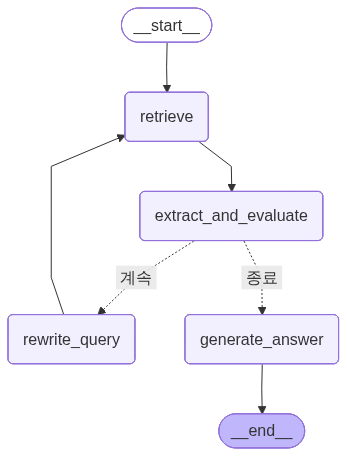

In [ ]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

workflow = StateGraph(Bank_of_Korea_RagState)

workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("extract_and_evaluate", extract_and_evaluate_information)
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("generate_answer", generate_node_answer)


workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "extract_and_evaluate")

workflow.add_conditional_edges(
    "extract_and_evaluate",
    should_continue,
    {
        "계속": "rewrite_query",
        "종료": "generate_answer"
    }
)
workflow.add_edge("rewrite_query", "retrieve")
workflow.add_edge("generate_answer", END)

Bank_of_Korea_act_agent = workflow.compile()

display(Image(Bank_of_Korea_act_agent.get_graph().draw_mermaid_png()))

In [41]:
inputs = {"question": "한국은행이 발행할 수 있는 통화의 종류와 한계는 무엇인가요?"}
for output in Bank_of_Korea_act_agent.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

---문서 검색---
"Node 'retrieve':"
("Value: {'documents': [Document(metadata={'chapter': '제4장 한국은행의 업무 <개정 2016. "
 "3. 29.>\\n         제1절 한국은행권의 발행 <개정 2016. 3. 29.>', 'name': '한국은행법', "
 "'source': 'data/한국은행법(법률)(제19409호)(20240517).pdf'}, "
 "page_content='[법률정보]\\n다음 조항은 한국은행법 제4장 한국은행의 업무 <개정 2016. 3. "
 '29.>\\n         제1절 한국은행권의 발행 <개정 2016. 3. 29.>에서 발췌한 '
 '내용입니다.\\n\\n[법률조항]\\n제47조(화폐의 발행) 화폐의 발행권은 한국은행만이 가진다.\\n[전문개정 2016. 3. '
 "29.]'), Document(metadata={'chapter': '제4장 한국은행의 업무 <개정 2016. 3. "
 "29.>\\n         제1절 한국은행권의 발행 <개정 2016. 3. 29.>', 'name': '한국은행법', 'source': "
 "'data/한국은행법(법률)(제19409호)(20240517).pdf'}, page_content='[법률정보]\\n다음 조항은 "
 '한국은행법 제4장 한국은행의 업무 <개정 2016. 3. 29.>\\n         제1절 한국은행권의 발행 <개정 2016. 3. '
 '29.>에서 발췌한 내용입니다.\\n\\n[법률조항]\\n제47조(화폐의 발행) 화폐의 발행권은 한국은행만이 가진다.\\n[전문개정 '
 "2016. 3. 29.]')]}")

----------------------------------------------------------

---정보 추출 및 평가---
"Node 'extract_and_evaluate':"
("Value: {'num_generations': 1, 'extracted_in

In [42]:
print(value['node_answer'])

# 한국은행이 발행할 수 있는 통화의 종류와 한계

## 1. 직접적인 답변
한국은행은 오직 원화(한국의 법정 통화)만을 발행할 수 있으며, 그 발행은 법률에 의해 규제됩니다. 통화 발행에는 경제 안정성을 유지하기 위한 법적 한계가 존재합니다.

## 2. 관련 법률 조항 및 해석
- **발행권**: 한국은행만이 화폐의 발행권을 가집니다. (출처: 한국은행법 제47조)
- **법적 규제**: 한국은행의 화폐 발행은 법률에 의해 규제되며, 이는 경제 안정성을 유지하기 위한 조치입니다. (출처: 한국은행법 제4장 한국은행의 업무)
- **통화의 종류**: 한국은행이 발행할 수 있는 통화의 종류는 법률에 명시되어 있지 않지만, 일반적으로 원화를 발행합니다. (출처: 한국은행법 제4장 한국은행의 업무)

## 3. 추가 설명 또는 예시
한국은행의 통화 발행은 물가 안정과 경제 성장 목표에 부합해야 하며, 이는 통화 정책의 일환으로 경제 전반에 긍정적인 영향을 미치기 위한 것입니다. 예를 들어, 통화량을 조절하여 인플레이션을 억제하거나 경제 성장을 촉진하는 등의 역할을 수행합니다.

## 4. 결론 및 요약
결론적으로, 한국은행은 원화만을 발행할 수 있으며, 그 발행은 법률에 의해 엄격히 규제됩니다. 통화 발행은 경제 안정성을 유지하기 위한 법적 한계를 가지고 있으며, 물가 안정과 경제 성장 목표에 부합해야 합니다. 이러한 규제는 한국 경제의 건강한 발전을 도모하기 위한 중요한 요소입니다.


In [ ]:
class Agricultural_RagState(CorrectiveRagState):
    rewritten_query: str  
    extracted_info: Optional[ExtractedInformation]  
    node_answer: Optional[str]

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal

def retrieve_documents(state: Agricultural_RagState) -> Agricultural_RagState:
    print("---문서 검색---")
    query = state.get("rewritten_query", state["question"])
    docs = Agricultural_act_search.invoke(query)
    return {"documents": docs}

def extract_and_evaluate_information(state: Agricultural_RagState) -> Agricultural_RagState:
    print("---정보 추출 및 평가---")
    extracted_strips = []

    for doc in state["documents"]:
        extract_prompt = ChatPromptTemplate.from_messages([
            ("system", """당신은 농수산물 유통 및 가격안정에 관한 법률 전문가입니다. 주어진 문서에서 질문과 관련된 주요 사실과 정보를 3~5개 정도 추출하세요. 
            각 추출된 정보에 대해 다음 두 가지 측면을 0에서 1 사이의 점수로 평가하세요:
            1. 질문과의 관련성
            2. 답변의 충실성 (질문에 대한 완전하고 정확한 답변을 제공할 수 있는 정도)
            
            추출 형식:
            1. [추출된 정보]
            - 관련성 점수: [0-1 사이의 점수]
            - 충실성 점수: [0-1 사이의 점수]
            2. [추출된 정보]
            - 관련성 점수: [0-1 사이의 점수]
            - 충실성 점수: [0-1 사이의 점수]

            
            마지막으로, 추출된 정보를 종합하여 질문에 대한 전반적인 답변 가능성을 0에서 1 사이의 점수로 평가하세요."""),
            ("human", "[질문]\n{question}\n\n[문서 내용]\n{document_content}")
        ])

        extract_llm = llm.with_structured_output(ExtractedInformation)

        extracted_data = extract_llm.invoke(extract_prompt.format(
            question=state["question"],
            document_content=doc.page_content
        ))

        if extracted_data.query_relevance < 0.8:
            continue

        for strip in extracted_data.strips:
            if strip.relevance_score > 0.7 and strip.faithfulness_score > 0.7:
                extracted_strips.append(strip)

    return {
        "extracted_info": extracted_strips,
        "num_generations": state.get("num_generations", 0) + 1
    }

def rewrite_query(state: Agricultural_RagState) -> Agricultural_RagState:
    print("---쿼리 재작성---")

    rewrite_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 농수산물 유통 및 가격안정에 관한 법률 전문가입니다. 주어진 원래 질문과 추출된 정보를 바탕으로, 더 관련성 있고 충실한 정보를 찾기 위해 검색 쿼리를 개선해주세요.

        다음 사항을 고려하여 검색 쿼리를 개선하세요:
        1. 원래 질문의 핵심 요소
        2. 추출된 정보의 관련성 점수
        3. 추출된 정보의 충실성 점수
        4. 부족한 정보나 더 자세히 알아야 할 부분

        개선된 검색 쿼리 작성 단계:
        1. 2-3개의 검색 쿼리를 제안하세요.
        2. 각 쿼리는 구체적이고 간결해야 합니다(5-10 단어 사이).
        3. 농수산물 유통 및 가격안정에 관한 법률과 관련된 전문 용어를 적절히 활용하세요.
        4. 각 쿼리 뒤에는 해당 쿼리를 제안한 이유를 간단히 설명하세요.

        출력 형식:
        1. [개선된 검색 쿼리 1]
        - 이유: [이 쿼리를 제안한 이유 설명]
        2. [개선된 검색 쿼리 2]
        - 이유: [이 쿼리를 제안한 이유 설명]
        3. [개선된 검색 쿼리 3]
        - 이유: [이 쿼리를 제안한 이유 설명]

        마지막으로, 제안된 쿼리 중 가장 효과적일 것 같은 쿼리를 선택하고 그 이유를 설명하세요."""),
        ("human", "원래 질문: {question}\n\n추출된 정보:\n{extracted_info}\n\n위 지침에 따라 개선된 검색 쿼리를 작성해주세요.")
    ])

    extracted_info_str = "\n".join([strip.content for strip in state["extracted_info"]])
    
    rewrite_llm = llm.with_structured_output(RefinedQuestion)

    response = rewrite_llm.invoke(rewrite_prompt.format(
        question=state["question"],
        extracted_info=extracted_info_str
    ))
    
    return {"rewritten_query": response.question_refined}

def generate_node_answer(state: Agricultural_RagState) -> Agricultural_RagState:
    print("---답변 생성---")

    answer_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 농수산물 유통 및 가격안정에 관한 법률 전문가입니다. 주어진 질문과 추출된 정보를 바탕으로 답변을 생성해주세요. 
        답변은 마크다운 형식으로 작성하며, 각 정보의 출처를 명확히 표시해야 합니다. 
        답변 구조:
        1. 질문에 대한 직접적인 답변
        2. 관련 법률 조항 및 해석
        3. 추가 설명 또는 예시 (필요한 경우)
        4. 결론 및 요약
        각 섹션에서 사용된 정보의 출처를 괄호 안에 명시하세요. 예: (출처: 농수산물 유통 및 가격안정에 관한 법률 제15조)"""),
        ("human", "질문: {question}\n\n추출된 정보:\n{extracted_info}\n\n위 지침에 따라 최종 답변을 작성해주세요.")
    ])

    extracted_info_str = "\n".join([f"내용: {strip.content}\n출처: {strip.source}\n관련성: {strip.relevance_score}\n충실성: {strip.faithfulness_score}" for strip in state["extracted_info"]])

    node_answer = llm.invoke(answer_prompt.format(
        question=state["question"],
        extracted_info=extracted_info_str
    ))

    return {"node_answer": node_answer.content}

def should_continue(state: Agricultural_RagState) -> Literal["계속", "종료"]:
    if state["num_generations"] >= 2:
        return "종료"
    if len(state["extracted_info"]) >= 1:
        return "종료"
    return "계속"

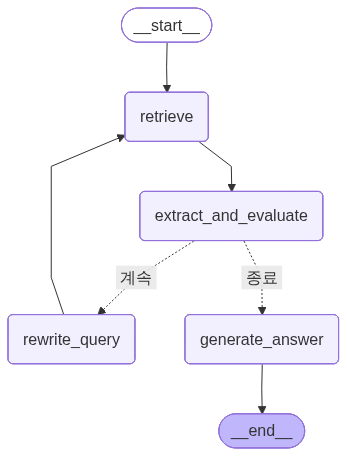

In [ ]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

workflow = StateGraph(Agricultural_RagState)

workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("extract_and_evaluate", extract_and_evaluate_information)
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("generate_answer", generate_node_answer)


workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "extract_and_evaluate")

workflow.add_conditional_edges(
    "extract_and_evaluate",
    should_continue,
    {
        "계속": "rewrite_query",
        "종료": "generate_answer"
    }
)
workflow.add_edge("rewrite_query", "retrieve")
workflow.add_edge("generate_answer", END)

Agricultural_act_agent = workflow.compile()

display(Image(Agricultural_act_agent.get_graph().draw_mermaid_png()))

In [46]:
inputs = {"question": "농수산물 유통 및 가격안정에 관한 법률의 목적이 뭐야?"}
for output in Agricultural_act_agent.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

---문서 검색---
"Node 'retrieve':"
("Value: {'documents': [Document(metadata={}, page_content='관련 정보를 찾을 수 "
 "없습니다.')]}")

----------------------------------------------------------

---정보 추출 및 평가---
"Node 'extract_and_evaluate':"
("Value: {'num_generations': 1, 'extracted_info': "
 "[InformationStrip(content='농수산물 유통 및 가격안정에 관한 법률은 농수산물의 유통을 원활하게 하고 가격을 "
 "안정시키기 위한 법률이다.', source='농수산물 유통 및 가격안정법 제1조', relevance_score=1.0, "
 "faithfulness_score=1.0), InformationStrip(content='이 법률의 목적은 농수산물의 생산자와 소비자 "
 "간의 공정한 거래를 촉진하는 것이다.', source='농수산물 유통 및 가격안정법 제1조', relevance_score=0.9, "
 "faithfulness_score=0.9), InformationStrip(content='농수산물의 가격 변동을 최소화하여 소비자와 "
 "생산자의 이익을 보호하는 것이 이 법의 주요 목표 중 하나이다.', source='농수산물 유통 및 가격안정법 제1조', "
 "relevance_score=0.8, faithfulness_score=0.8), InformationStrip(content='이 법은 "
 "농수산물의 수급 조절을 통해 시장의 안정성을 도모하는 역할을 한다.', source='농수산물 유통 및 가격안정법 제1조', "
 'relevance_score=0.85, faithfulness_score=0.85)]}')

------------------------------------------------------

In [47]:
print(value['node_answer'])

# 농수산물 유통 및 가격안정에 관한 법률의 목적

## 1. 질문에 대한 직접적인 답변
농수산물 유통 및 가격안정에 관한 법률의 목적은 농수산물의 유통을 원활하게 하고 가격을 안정시키며, 생산자와 소비자 간의 공정한 거래를 촉진하는 것입니다. 또한, 농수산물의 가격 변동을 최소화하여 소비자와 생산자의 이익을 보호하는 것을 주요 목표로 하고 있습니다.

## 2. 관련 법률 조항 및 해석
이 법률의 목적은 다음과 같이 명시되어 있습니다:
- **농수산물 유통 및 가격안정법 제1조**: 이 법은 농수산물의 유통을 원활하게 하고 가격을 안정시키며, 생산자와 소비자 간의 공정한 거래를 촉진하는 것을 목적으로 한다. 또한, 농수산물의 가격 변동을 최소화하고, 수급 조절을 통해 시장의 안정성을 도모하는 역할을 한다.

## 3. 추가 설명 또는 예시
예를 들어, 농수산물의 가격이 급격히 상승할 경우, 이 법은 정부가 개입하여 가격을 안정시키기 위한 조치를 취할 수 있도록 합니다. 이는 생산자와 소비자 모두의 이익을 보호하기 위한 조치로, 시장의 불안정을 줄이는 데 기여합니다.

## 4. 결론 및 요약
농수산물 유통 및 가격안정에 관한 법률은 농수산물의 유통을 원활하게 하고 가격을 안정시키며, 공정한 거래를 촉진하는 것을 목적으로 합니다. 이 법은 가격 변동을 최소화하고 시장의 안정성을 도모하여 소비자와 생산자의 이익을 보호하는 중요한 역할을 합니다. (출처: 농수산물 유통 및 가격안정법 제1조)


In [ ]:
class Price_Stabilization_RagState(CorrectiveRagState):
    rewritten_query: str  
    extracted_info: Optional[ExtractedInformation]  
    node_answer: Optional[str] 

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal

def retrieve_documents(state: Price_Stabilization_RagState) -> Price_Stabilization_RagState:
    print("---문서 검색---")
    query = state.get("rewritten_query", state["question"])
    docs = Price_Stabilization_act_search.invoke(query)
    return {"documents": docs}

def extract_and_evaluate_information(state: Price_Stabilization_RagState) -> Price_Stabilization_RagState:
    print("---정보 추출 및 평가---")
    extracted_strips = []

    for doc in state["documents"]:
        extract_prompt = ChatPromptTemplate.from_messages([
            ("system", """당신은 물가안정에 관한 법률 전문가입니다. 주어진 문서에서 질문과 관련된 주요 사실과 정보를 3~5개 정도 추출하세요. 
            각 추출된 정보에 대해 다음 두 가지 측면을 0에서 1 사이의 점수로 평가하세요:
            1. 질문과의 관련성
            2. 답변의 충실성 (질문에 대한 완전하고 정확한 답변을 제공할 수 있는 정도)
            
            추출 형식:
            1. [추출된 정보]
            - 관련성 점수: [0-1 사이의 점수]
            - 충실성 점수: [0-1 사이의 점수]
            2. [추출된 정보]
            - 관련성 점수: [0-1 사이의 점수]
            - 충실성 점수: [0-1 사이의 점수]
            
            마지막으로, 추출된 정보를 종합하여 질문에 대한 전반적인 답변 가능성을 0에서 1 사이의 점수로 평가하세요."""),
            ("human", "[질문]\n{question}\n\n[문서 내용]\n{document_content}")
        ])

        extract_llm = llm.with_structured_output(ExtractedInformation)

        extracted_data = extract_llm.invoke(extract_prompt.format(
            question=state["question"],
            document_content=doc.page_content
        ))

        if extracted_data.query_relevance < 0.8:
            continue

        for strip in extracted_data.strips:
            if strip.relevance_score > 0.7 and strip.faithfulness_score > 0.7:
                extracted_strips.append(strip)

    return {
        "extracted_info": extracted_strips,
        "num_generations": state.get("num_generations", 0) + 1
    }

def rewrite_query(state: Price_Stabilization_RagState) -> Price_Stabilization_RagState:
    print("---쿼리 재작성---")

    rewrite_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 물가안정에 관한 법률 전문가입니다. 주어진 원래 질문과 추출된 정보를 바탕으로, 더 관련성 있고 충실한 정보를 찾기 위해 검색 쿼리를 개선해주세요.

        다음 사항을 고려하여 검색 쿼리를 개선하세요:
        1. 원래 질문의 핵심 요소
        2. 추출된 정보의 관련성 점수
        3. 추출된 정보의 충실성 점수
        4. 부족한 정보나 더 자세히 알아야 할 부분

        개선된 검색 쿼리 작성 단계:
        1. 2-3개의 검색 쿼리를 제안하세요.
        2. 각 쿼리는 구체적이고 간결해야 합니다(5-10 단어 사이).
        3. 물가안정에 관한 법률과 관련된 전문 용어를 적절히 활용하세요.
        4. 각 쿼리 뒤에는 해당 쿼리를 제안한 이유를 간단히 설명하세요.

        출력 형식:
        1. [개선된 검색 쿼리 1]
        - 이유: [이 쿼리를 제안한 이유 설명]
        2. [개선된 검색 쿼리 2]
        - 이유: [이 쿼리를 제안한 이유 설명]
        3. [개선된 검색 쿼리 3]
        - 이유: [이 쿼리를 제안한 이유 설명]

        마지막으로, 제안된 쿼리 중 가장 효과적일 것 같은 쿼리를 선택하고 그 이유를 설명하세요."""),
        ("human", "원래 질문: {question}\n\n추출된 정보:\n{extracted_info}\n\n위 지침에 따라 개선된 검색 쿼리를 작성해주세요.")
    ])

    extracted_info_str = "\n".join([strip.content for strip in state["extracted_info"]])
    
    rewrite_llm = llm.with_structured_output(RefinedQuestion)

    response = rewrite_llm.invoke(rewrite_prompt.format(
        question=state["question"],
        extracted_info=extracted_info_str
    ))
    
    return {"rewritten_query": response.question_refined}

def generate_node_answer(state: Price_Stabilization_RagState) -> Price_Stabilization_RagState:
    print("---답변 생성---")

    answer_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 물가안정에 관한 법률 전문가입니다. 주어진 질문과 추출된 정보를 바탕으로 답변을 생성해주세요. 
        답변은 마크다운 형식으로 작성하며, 각 정보의 출처를 명확히 표시해야 합니다. 
        답변 구조:
        1. 질문에 대한 직접적인 답변
        2. 관련 법률 조항 및 해석
        3. 추가 설명 또는 예시 (필요한 경우)
        4. 결론 및 요약
        각 섹션에서 사용된 정보의 출처를 괄호 안에 명시하세요. 예: (출처: 물가안정에 관한 법률 제15조)"""),
        ("human", "질문: {question}\n\n추출된 정보:\n{extracted_info}\n\n위 지침에 따라 최종 답변을 작성해주세요.")
    ])

    extracted_info_str = "\n".join([f"내용: {strip.content}\n출처: {strip.source}\n관련성: {strip.relevance_score}\n충실성: {strip.faithfulness_score}" for strip in state["extracted_info"]])

    node_answer = llm.invoke(answer_prompt.format(
        question=state["question"],
        extracted_info=extracted_info_str
    ))

    return {"node_answer": node_answer.content}

def should_continue(state: Price_Stabilization_RagState) -> Literal["계속", "종료"]:
    if state["num_generations"] >= 2:
        return "종료"
    if len(state["extracted_info"]) >= 1:
        return "종료"
    return "계속"

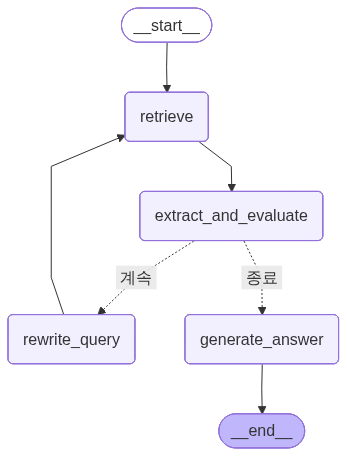

In [ ]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

workflow = StateGraph(Price_Stabilization_RagState)

workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("extract_and_evaluate", extract_and_evaluate_information)
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("generate_answer", generate_node_answer)


workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "extract_and_evaluate")

workflow.add_conditional_edges(
    "extract_and_evaluate",
    should_continue,
    {
        "계속": "rewrite_query",
        "종료": "generate_answer"
    }
)
workflow.add_edge("rewrite_query", "retrieve")
workflow.add_edge("generate_answer", END)

Price_Stabilization_act_agent = workflow.compile()

display(Image(Price_Stabilization_act_agent.get_graph().draw_mermaid_png()))

In [51]:
inputs = {"question": "물가안정법 제정 이후 농산물이나 필수재 가격안정 조치가 CPI 신선식품지수에 어떤 영향을 주었는가?"}
for output in Price_Stabilization_act_agent.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

---문서 검색---
"Node 'retrieve':"
("Value: {'documents': [Document(metadata={'name': '물가안정에 관한 법률', 'source': "
 "'data/물가안정에 관한 법률(법률)(제20404호)(20240927).pdf'}, page_content='[법률정보]\\n다음 "
 '조항은 물가안정에 관한 법률에서 발췌한 내용입니다.\\n\\n[법률조항]\\n제2조(최고가격의 지정 등) ① 정부는 내우외환, 천재지변, '
 '긴급한 재정ㆍ경제상의 위기 등 대통령령으로 정하는 사유\\n가 있는 경우로서 국민생활과 국민경제의 안정을 위하여 필요하다고 인정할 때에는 '
 '특히 중요한 물품의 가격, 부동\\n산 등의 임대료 또는 용역의 대가에 대하여 최고가액(이하 “최고가격”이라 한다)을 지정할 수 있다. '
 '<개정 2021. 1.\\n5.>\\n② 최고가격은 생산단계ㆍ도매단계ㆍ소매단계 등 거래단계별 및 지역별로 지정할 수 있다.\\n③ 정부는 '
 '제1항에 따라 지정한 최고가격을 계속 유지할 사유가 없어졌다고 인정할 때에는 지체 없이 폐지하여야\\n한다.\\n④ 정부는 제1항 또는 '
 '제3항에 따라 최고가격을 지정하거나 폐지하였을 때에는 지체 없이 그 사실을 고시하여야 한\\n다.\\n[전문개정 2011. 5. '
 "2.]'), Document(metadata={'name': '물가안정에 관한 법률', 'source': 'data/물가안정에 관한 "
 "법률(법률)(제20404호)(20240927).pdf'}, page_content='[법률정보]\\n다음 조항은 물가안정에 관한 법률에서 "
 '발췌한 내용입니다.\\n\\n[법률조항]\\n제2조(최고가격의 지정 등) ① 정부는 내우외환, 천재지변, 긴급한 재정ㆍ경제상의 위기 등 '
 '대통령령으로 정하는 사유\\n가 있는 경우로서 국민생활과 국민경제의 안정을 위하여 필요하다고 인정할 때에는 특히 중요한 물품의 가격, '
 '부동\\n산 등의 임대료 

In [52]:
print(value['node_answer'])

# 물가안정법 제정 이후 농산물 및 필수재 가격안정 조치가 CPI 신선식품지수에 미친 영향

## 1. 직접적인 답변
물가안정법 제정 이후 정부의 최고가격 지정 조치는 농산물 및 필수재의 가격안정에 기여하였으며, 이는 결과적으로 CPI 신선식품지수에 긍정적인 영향을 미쳤다고 볼 수 있습니다. 

## 2. 관련 법률 조항 및 해석
물가안정법 제2조에 따르면, 정부는 국민생활과 국민경제의 안정을 위해 최고가격을 지정할 수 있습니다. 이러한 최고가격 지정은 필수재 및 농산물의 가격안정에 기여할 수 있으며, 이는 CPI 신선식품지수에 직접적인 영향을 미칠 수 있습니다 (출처: 물가안정법 제2조).

또한, 물가안정법은 내우외환, 천재지변 등 긴급한 상황에서 가격안정을 위한 조치를 취할 수 있도록 규정하고 있습니다. 이러한 조치는 가격의 급등을 방지하고, 소비자에게 안정적인 가격을 제공하는 데 중요한 역할을 합니다 (출처: 물가안정법 제2조).

## 3. 추가 설명 또는 예시
예를 들어, 정부가 특정 농산물에 대해 최고가격을 설정하면, 해당 농산물의 가격이 급등하는 것을 방지할 수 있습니다. 이는 소비자들이 안정적인 가격으로 농산물을 구매할 수 있게 하여 CPI 신선식품지수의 변동성을 줄이는 데 기여합니다. 

또한, 이러한 조치는 농민들에게도 일정한 가격을 보장함으로써 생산 의욕을 높이고, 시장의 안정성을 유지하는 데 도움을 줍니다.

## 4. 결론 및 요약
결론적으로, 물가안정법의 최고가격 지정 조치는 농산물 및 필수재의 가격안정에 기여하며, 이는 CPI 신선식품지수에 긍정적인 영향을 미친다고 할 수 있습니다. 정부의 가격안정 조치는 소비자와 생산자 모두에게 이익을 주며, 경제 전반의 안정성을 높이는 데 중요한 역할을 합니다 (출처: 물가안정법 제2조).


In [ ]:
class SearchRagState(CorrectiveRagState):
    rewritten_query: str    
    extracted_info: Optional[ExtractedInformation]   
    node_answer: Optional[str] 

In [ ]:
from langchain_core.prompts import ChatPromptTemplate
from typing import Literal

def retrieve_documents(state: SearchRagState) -> SearchRagState:
    print("---문서 검색---")
    query = state.get("rewritten_query", state["question"])
    docs = web_search.invoke(query)
    return {"documents": docs}

def extract_and_evaluate_information(state: SearchRagState) -> SearchRagState:
    print("---정보 추출 및 평가---")
    extracted_strips = []

    for doc in state["documents"]:
        extract_prompt = ChatPromptTemplate.from_messages([
            ("system", """당신은 인터넷 정보 검색 전문가입니다. 주어진 문서에서 질문과 관련된 주요 사실과 정보를 3~5개 정도 추출하세요. 
            각 추출된 정보에 대해 다음 두 가지 측면을 0에서 1 사이의 점수로 평가하세요:
            1. 질문과의 관련성
            2. 답변의 충실성 (질문에 대한 완전하고 정확한 답변을 제공할 수 있는 정도)
            
            추출 형식:
            1. [추출된 정보]
            - 관련성 점수: [0-1 사이의 점수]
            - 충실성 점수: [0-1 사이의 점수]
            2. [추출된 정보]
            - 관련성 점수: [0-1 사이의 점수]
            - 충실성 점수: [0-1 사이의 점수]
            
            마지막으로, 추출된 정보를 종합하여 질문에 대한 전반적인 답변 가능성을 0에서 1 사이의 점수로 평가하세요."""),
            ("human", "[질문]\n{question}\n\n[문서 내용]\n{document_content}")
        ])

        extract_llm = llm.with_structured_output(ExtractedInformation)

        extracted_data = extract_llm.invoke(extract_prompt.format(
            question=state["question"],
            document_content=doc.page_content
        ))

        if extracted_data.query_relevance < 0.8:
            continue

        for strip in extracted_data.strips:
            if strip.relevance_score > 0.7 and strip.faithfulness_score > 0.7:
                extracted_strips.append(strip)

    return {
        "extracted_info": extracted_strips,
        "num_generations": state.get("num_generations", 0) + 1
    }

def rewrite_query(state: SearchRagState) -> SearchRagState:
    print("---쿼리 재작성---")

    rewrite_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 인터넷 정보 검색 전문가입니다. 주어진 원래 질문과 추출된 정보를 바탕으로, 더 관련성 있고 충실한 정보를 찾기 위해 검색 쿼리를 개선해주세요.

        다음 사항을 고려하여 검색 쿼리를 개선하세요:
        1. 원래 질문의 핵심 요소
        2. 추출된 정보의 관련성 점수
        3. 추출된 정보의 충실성 점수
        4. 부족한 정보나 더 자세히 알아야 할 부분

        개선된 검색 쿼리 작성 단계:
        1. 2-3개의 검색 쿼리를 제안하세요.
        2. 각 쿼리는 구체적이고 간결해야 합니다(5-10 단어 사이).
        3. 질문과 관련된 전문 용어를 적절히 활용하세요.
        4. 각 쿼리 뒤에는 해당 쿼리를 제안한 이유를 간단히 설명하세요.

        출력 형식:
        1. [개선된 검색 쿼리 1]
        - 이유: [이 쿼리를 제안한 이유 설명]
        2. [개선된 검색 쿼리 2]
        - 이유: [이 쿼리를 제안한 이유 설명]
        3. [개선된 검색 쿼리 3]
        - 이유: [이 쿼리를 제안한 이유 설명]

        마지막으로, 제안된 쿼리 중 가장 효과적일 것 같은 쿼리를 선택하고 그 이유를 설명하세요."""),
        ("human", "원래 질문: {question}\n\n추출된 정보:\n{extracted_info}\n\n위 지침에 따라 개선된 검색 쿼리를 작성해주세요.")
    ])

    extracted_info_str = "\n".join([strip.content for strip in state["extracted_info"]])
    
    rewrite_llm = llm.with_structured_output(RefinedQuestion)

    response = rewrite_llm.invoke(rewrite_prompt.format(
        question=state["question"],
        extracted_info=extracted_info_str
    ))
    
    return {"rewritten_query": response.question_refined}

def generate_node_answer(state: SearchRagState) -> SearchRagState:
    print("---답변 생성---")

    answer_prompt = ChatPromptTemplate.from_messages([
        ("system", """당신은 인터넷 정보 검색 전문가입니다. 주어진 질문과 추출된 정보를 바탕으로 답변을 생성해주세요. 
        답변은 마크다운 형식으로 작성하며, 각 정보의 출처를 명확히 표시해야 합니다. 
        답변 구조:
        1. 질문에 대한 직접적인 답변
        2. 관련 출처 및 링크
        3. 추가 설명 또는 예시 (필요한 경우)
        4. 결론 및 요약
        각 섹션에서 사용된 정보의 출처를 괄호 안에 명시하세요. 예: (출처: 블로그 (www.blog.com/page/001)"""),
        ("human", "질문: {question}\n\n추출된 정보:\n{extracted_info}\n\n위 지침에 따라 최종 답변을 작성해주세요.")
    ])

    extracted_info_str = "\n".join([f"내용: {strip.content}\n출처: {strip.source}\n관련성: {strip.relevance_score}\n충실성: {strip.faithfulness_score}" for strip in state["extracted_info"]])

    node_answer = llm.invoke(answer_prompt.format(
        question=state["question"],
        extracted_info=extracted_info_str
    ))

    return {"node_answer": node_answer.content}

def should_continue(state: SearchRagState) -> Literal["계속", "종료"]:
    if state["num_generations"] >= 2:
        return "종료"
    if len(state["extracted_info"]) >= 1:
        return "종료"
    return "계속"

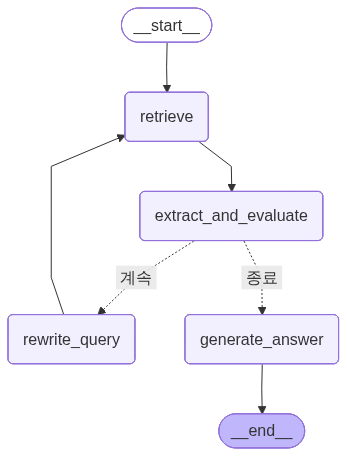

In [ ]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display

workflow = StateGraph(SearchRagState)

workflow.add_node("retrieve", retrieve_documents)
workflow.add_node("extract_and_evaluate", extract_and_evaluate_information)
workflow.add_node("rewrite_query", rewrite_query)
workflow.add_node("generate_answer", generate_node_answer)


workflow.add_edge(START, "retrieve")
workflow.add_edge("retrieve", "extract_and_evaluate")

workflow.add_conditional_edges(
    "extract_and_evaluate",
    should_continue,
    {
        "계속": "rewrite_query",
        "종료": "generate_answer"
    }
)
workflow.add_edge("rewrite_query", "retrieve")
workflow.add_edge("generate_answer", END)

search_web_agent = workflow.compile()

display(Image(search_web_agent.get_graph().draw_mermaid_png()))

In [ ]:
inputs = {"question": "농수산물 유통 및 가격안정에 관한 법률의 목적이 무엇인가요?"}
for output in search_web_agent.stream(inputs):
    for key, value in output.items():
        
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

---문서 검색---
"Node 'retrieve':"
("Value: {'documents': [Document(metadata={'source': 'web search', 'url': "
 "'https://at.agromarket.kr/whsal/etc.do?etcSeq=12'}, page_content='<Document "
 'href="https://at.agromarket.kr/whsal/etc.do?etcSeq=12"/>\\n농안법이란 농수산물 유통 및 '
 '가격 안정에 관한 법률의 약칭으로 정부가 농수산물 도매시장의 왜곡된 거래관행을 바로 잡아 가격 안정을 도모하기 위해 마련한 '
 "법률이다.\\n</Document>'), Document(metadata={'source': 'web search', 'url': "
 "'https://bigcase.ai/law/%EB%86%8D%EC%88%98%EC%82%B0%EB%AC%BC%EC%9C%A0%ED%86%B5%EB%B0%8F%EA%B0%80%EA%B2%A9%EC%95%88%EC%A0%95%EC%97%90%EA%B4%80%ED%95%9C%EB%B2%95%EB%A5%A0/?refDate=20230816'}, "
 "page_content='<Document "
 'href="https://bigcase.ai/law/%EB%86%8D%EC%88%98%EC%82%B0%EB%AC%BC%EC%9C%A0%ED%86%B5%EB%B0%8F%EA%B0%80%EA%B2%A9%EC%95%88%EC%A0%95%EC%97%90%EA%B4%80%ED%95%9C%EB%B2%95%EB%A5%A0/?refDate=20230816"/>\\n이 '
 '법은 농수산물의 유통을 원활하게 하고 적정한 가격을 유지하게 함으로써 생산자와 소비자의 이익을 보호하고 국민생활의 안정에 이바지함을 '
 "목적으로 한다.\\n</Document>')]}")

-------------------------------------------------

In [57]:
print(value['node_answer'])

# 농수산물 유통 및 가격안정에 관한 법률의 목적

농수산물 유통 및 가격안정에 관한 법률의 주요 목적은 다음과 같습니다:

1. **가격 안정 도모**: 정부가 농수산물 도매시장에서의 왜곡된 거래관행을 바로잡아 가격을 안정시키기 위해 마련된 법률입니다.
2. **유통 원활화 및 이익 보호**: 농수산물의 유통을 원활하게 하고 적정한 가격을 유지함으로써 생산자와 소비자의 이익을 보호하고, 국민생활의 안정에 기여하는 것을 목표로 하고 있습니다.

이 법률은 농수산물의 유통 구조를 개선하고, 가격 변동성을 줄여 생산자와 소비자 모두에게 이익이 되는 환경을 조성하는 데 중점을 두고 있습니다.

## 관련 출처
- 농수산물 유통 및 가격안정에 관한 법률 (https://at.agromarket.kr/whsal/etc.do?etcSeq=12)

## 추가 설명
이 법률은 농수산물 시장의 투명성을 높이고, 불공정 거래를 방지하기 위한 다양한 조치를 포함하고 있습니다. 예를 들어, 도매시장에 대한 규제를 강화하고, 가격 정보의 공개를 의무화하여 시장 참여자들이 보다 공정하게 거래할 수 있도록 지원합니다.

## 결론 및 요약
농수산물 유통 및 가격안정에 관한 법률은 농수산물의 가격을 안정시키고 유통을 원활하게 하여 생산자와 소비자의 이익을 보호하는 것을 목적으로 하고 있습니다. 이를 통해 국민생활의 안정에도 기여하고 있습니다.


In [ ]:
from typing import Annotated
from operator import add

class ResearchAgentState(TypedDict):
    question: str
    answers: Annotated[List[str], add]
    final_answer: str
    datasources: List[str]
    evaluation_report: Optional[dict]
    user_decision: Optional[str]

In [59]:
from typing import Literal
from langchain_core.prompts import ChatPromptTemplate
from pydantic import BaseModel, Field

# 라우팅 결정을 위한 데이터 모델
class ToolSelector(BaseModel):
    """Routes the user question to the most appropriate tool."""
    tool: Literal["Bank_of_Korea_act_search", "Agricultural_act_search", "Price_Stabilization_act_search", "search_web"] = Field(
        description="Select one of the tools, based on the user's question.",
    )

class ToolSelectors(BaseModel):
    """Select the appropriate tools that are suitable for the user question."""
    tools: List[ToolSelector] = Field(
        description="Select one or more tools, based on the user's question.",
    )

# 구조화된 출력을 위한 LLM 설정
structured_llm_tool_selector = llm.with_structured_output(ToolSelectors)

# 라우팅을 위한 프롬프트 템플릿
system = dedent("""You are an AI assistant specializing in routing user questions to the appropriate tools.
Use the following guidelines:
- For questions specifically about legal provisions or articles of the privacy Bank of Korea Act (한국은행법), use the Bank_of_Korea_act_search tool.
- For questions specifically about legal provisions or articles of the Act on Distribution of Agricultural and Fishery Products and Price Stabilization (농수산물 유통 및 가격안정에 관한 법률), use the Agricultural_act_search tool.
- For questions specifically about legal provisions or articles of the Price Stabilization Act (물가안정에 관한 법률), use the Price_Stabilization_act_search tool.
- For any other information, including questions related to these laws but not directly about specific legal provisions, or for the most up-to-date data, use the search_web tool.
Always choose all of the appropriate tools based on the user's question. 
If a question is about a law but doesn't seem to be asking about specific legal provisions, include both the relevant law search tool and the search_web tool.""")

route_prompt = ChatPromptTemplate.from_messages(
    [
        ("system", system),
        ("human", "{question}"),
    ]
)

# 질문 라우터 정의
question_tool_router = route_prompt | structured_llm_tool_selector

# 테스트 실행
print(question_tool_router.invoke({"question": "한국은행법에서 규정하는 통화신용정책 수단이 소비자물가지수(CPI) 안정에 어떤 역할을 하는가?"}))
print(question_tool_router.invoke({"question": "농수산물 유통 및 가격안정에 관한 법률의 비축사업(제13조)이 신선식품지수 등 CPI 변동성 완화에 어떻게 기여했는가?"}))
print(question_tool_router.invoke({"question": "물가안정에 관한 법률에서 규정하는 정부의 가격조정 및 긴급조치 권한이 소비자물가지수(CPI) 안정 정책과 어떻게 연계되는가?"}))

tools=[ToolSelector(tool='Bank_of_Korea_act_search'), ToolSelector(tool='search_web')]
tools=[ToolSelector(tool='Agricultural_act_search'), ToolSelector(tool='search_web')]
tools=[ToolSelector(tool='Price_Stabilization_act_search'), ToolSelector(tool='search_web')]


In [ ]:

def analyze_question_tool_search(state: ResearchAgentState):
    question = state["question"]
    result = question_tool_router.invoke({"question": question})
    datasources = [tool.tool for tool in result.tools]
    return {"datasources": datasources}


def route_datasources_tool_search(state: ResearchAgentState) -> List[str]:
    datasources = set(state['datasources'])
    valid_sources = {"Bank_of_Korea_act_search", "Agricultural_act_search", "Price_Stabilization_act_search", "search_web"}
        
    if datasources.issubset(valid_sources):
        return list(datasources)
    
    return list(valid_sources)

In [ ]:

def Bank_of_Korea_rag_node(state: Bank_of_Korea_RagState, input=ResearchAgentState) -> ResearchAgentState:
    print("--- 한국은행법 전문가 에이전트 시작 ---")
    question = state["question"]
    answer = Bank_of_Korea_act_agent.invoke({"question": question})
    return {"answers": [answer["node_answer"]]}

def Agricultural_rag_node(state: Agricultural_RagState, input=ResearchAgentState) -> ResearchAgentState:
    print("--- 농수산물 유통 및 가격안정에 관한 법률 전문가 에이전트 시작 ---")
    question = state["question"]
    answer = Agricultural_act_agent.invoke({"question": question})
    return {"answers": [answer["node_answer"]]}

def Price_Stabilization_rag_node(state: Price_Stabilization_RagState, input=ResearchAgentState) -> ResearchAgentState:
    print("--- 물가안정에 관한 법률 전문가 에이전트 시작 ---")
    question = state["question"]
    answer = Price_Stabilization_act_agent.invoke({"question": question})
    return {"answers": [answer["node_answer"]]}

def web_rag_node(state: SearchRagState, input=ResearchAgentState) -> ResearchAgentState:
    print("--- 인터넷 검색 전문가 에이전트 시작 ---")
    question = state["question"]
    answer = search_web_agent.invoke({"question": question})
    return {"answers": [answer["node_answer"]]}


In [ ]:
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate

rag_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an assistant answering questions based on provided documents. Follow these guidelines:

1. Use only information from the given documents.
2. If the document lacks relevant info, say "제공된 정보로는 충분한 답변을 할 수 없습니다."
3. Cite the source of information for each sentence in your answer. Use the following format:
    - For legal articles: "법률명 제X조 Y항"
    - For web sources: "출처 제목 (URL)"
4. Don't speculate or add information not in the documents.
5. Keep answers concise and clear.
6. Omit irrelevant information.
7. If multiple sources provide the same information, cite all relevant sources.
8. If information comes from multiple sources, combine them coherently while citing each source.

Example of citation usage:
"부동산 거래 시 계약서에 거래 금액을 명시해야 합니다 (부동산 거래신고 등에 관한 법률 제3조 1항). 또한, 계약 체결일로부터 30일 이내에 신고해야 합니다 (부동산 거래 신고 안내 블로그, https://example.com/realestate)."
"""
    ),
    ("human", "Answer the following question using these documents:\n\n[Documents]\n{documents}\n\n[Question]\n{question}"),
])

def answer_final(state: ResearchAgentState) -> ResearchAgentState:
    """
    Generate answer using the retrieved_documents
    """
    print("---최종 답변---")
    question = state["question"]
    documents = state.get("answers", [])
    if not isinstance(documents, list):
        documents = [documents]
 
    documents_text = "\n\n".join(documents)

    rag_chain = rag_prompt | llm | StrOutputParser()
    generation = rag_chain.invoke({"documents": documents_text, "question": question})
    return {"final_answer": generation, "question":question}


fallback_prompt = ChatPromptTemplate.from_messages([
    ("system", """You are an AI assistant helping with various topics. Follow these guidelines:

1. Provide accurate and helpful information to the best of your ability.
2. Express uncertainty when unsure; avoid speculation.
3. Keep answers concise yet informative.
4. Respond ethically and constructively.
5. Mention reliable general sources when applicable."""),
    ("human", "{question}"),
])

def llm_fallback(state: ResearchAgentState) -> ResearchAgentState:
    """
    Generate answer using the LLM without context
    """
    print("---Fallback 답변---")
    question = state["question"]
    
    llm_chain = fallback_prompt | llm | StrOutputParser()
    
    generation = llm_chain.invoke({"question": question})
    return {"final_answer": generation, "question":question}

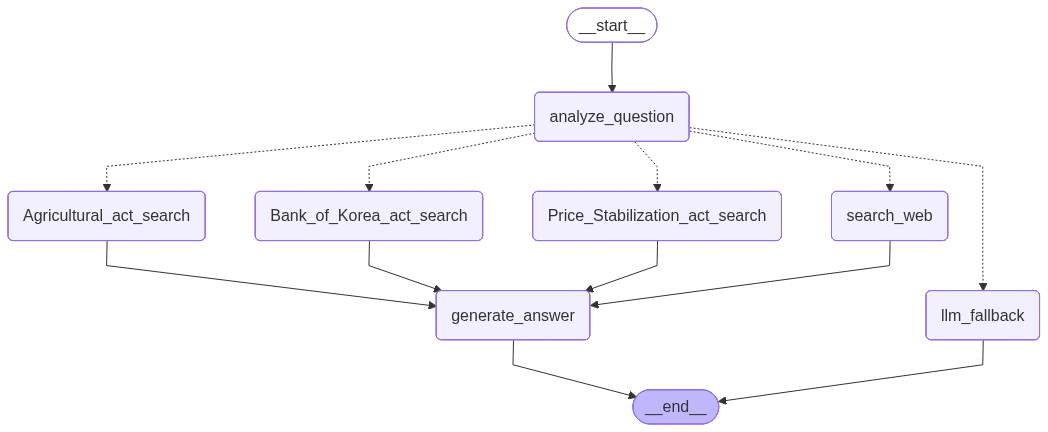

In [ ]:
nodes = {
    "analyze_question": analyze_question_tool_search,
    "Bank_of_Korea_act_search": Bank_of_Korea_rag_node,
    "Agricultural_act_search": Agricultural_rag_node,
    "Price_Stabilization_act_search": Price_Stabilization_rag_node,
    "search_web": web_rag_node,
    "generate_answer": answer_final,
    "llm_fallback": llm_fallback
}

search_builder = StateGraph(ResearchAgentState)

for node_name, node_func in nodes.items():
    search_builder.add_node(node_name, node_func)

search_builder.add_edge(START, "analyze_question")
search_builder.add_conditional_edges(
    "analyze_question",
    route_datasources_tool_search,
    ["Bank_of_Korea_act_search", "Agricultural_act_search", "Price_Stabilization_act_search", "search_web", "llm_fallback"]
)

for node in ["Bank_of_Korea_act_search", "Agricultural_act_search", "Price_Stabilization_act_search", "search_web"]:
    search_builder.add_edge(node, "generate_answer")

search_builder.add_edge("generate_answer", END)
search_builder.add_edge("llm_fallback", END)

rag_search_graph = search_builder.compile()

display(Image(rag_search_graph.get_graph().draw_mermaid_png()))

In [ ]:
inputs = {"question": "한국은행법에서 규정하는 통화정책 수단과 국채 인수 제한이 소비자물가지수(CPI) 안정과 물가안정 정책에 어떤 영향을 미치는가?"}
for output in rag_search_graph.stream(inputs):
    for key, value in output.items():
        
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

"Node 'analyze_question':"
"Value: {'datasources': ['Bank_of_Korea_act_search', 'search_web']}"

----------------------------------------------------------

--- 한국은행법 전문가 에이전트 시작 ---
---문서 검색---
--- 인터넷 검색 전문가 에이전트 시작 ---
---문서 검색---
---정보 추출 및 평가---
---정보 추출 및 평가---
---답변 생성---
"Node 'Bank_of_Korea_act_search':"
("Value: {'answers': ['# 한국은행법에서 규정하는 통화정책 수단과 국채 인수 제한의 소비자물가지수(CPI) 안정 및 "
 '물가안정 정책에 대한 영향\\n\\n## 1. 직접적인 답변\\n한국은행법에 따라 한국은행은 물가안정목표를 설정하고 이를 달성하기 위해 '
 '통화정책 수단을 활용합니다. 국채 인수 제한은 정부의 재정정책과 통화정책 간의 조화를 유지하는 데 기여하여 물가안정에 긍정적인 영향을 '
 '미칩니다.\\n\\n## 2. 관련 법률 조항 및 해석\\n- **물가안정목표 설정**: 한국은행은 정부와 협의하여 물가안정목표를 정해야 '
 '하며, 이를 달성하기 위해 최선을 다해야 합니다 (출처: 한국은행법 제6조).\\n- **통화신용정책 운영방향**: 한국은행은 매년 '
 '통화신용정책 운영방향을 수립하고 이를 공표해야 합니다 (출처: 한국은행법 제6조).\\n- **국채 인수 제한**: 국채 인수 제한은 '
 '정부의 재정정책과 통화정책 간의 조화를 유지하는 데 기여합니다 (출처: 일반적인 경제 이론).\\n\\n## 3. 추가 설명 또는 '
 '예시\\n한국은행이 설정한 물가안정목표는 소비자물가지수(CPI)의 안정과 직결됩니다. 예를 들어, 통화정책 수단으로 금리를 조정하거나 '
 '유동성을 관리함으로써 물가 상승률을 조절할 수 있습니다. 국채 인수 제한은 정부가 과도한 재정적

In [71]:
print(value['final_answer'])

한국은행법에 따라 한국은행은 물가안정목표를 설정하고 이를 달성하기 위해 통화정책 수단을 활용합니다 (한국은행법 제6조). 이러한 통화정책 수단은 금리 조정, 공개시장 조작, 지급준비율 조정 등을 포함하며, 물가를 안정시키는 데 기여합니다 (출처: KDI 연구 분석, https://www.kdi.re.kr/research/analysisView?art_no=3626). 

국채 인수 제한은 정부의 재정정책과 통화정책 간의 조화를 유지하여 물가안정에 긍정적인 영향을 미칩니다 (출처: 일반적인 경제 이론). 이는 정부가 과도한 재정적자를 피하도록 하여 통화정책의 효과성을 높이는 역할을 합니다. 

결과적으로, 한국은행의 통화정책 수단은 소비자물가지수(CPI)의 안정에 긍정적인 영향을 미치며, 물가상승률에 지속적인 영향을 미치는 중요한 요소입니다 (출처: KDI 연구 분석, https://www.kdi.re.kr/research/analysisView?art_no=3626).


In [65]:
from textwrap import dedent

evaluation_prompt = dedent("""
당신은 AI 어시스턴트가 생성한 답변을 평가하는 전문가입니다. 주어진 질문과 답변을 평가하고, 60점 만점으로 점수를 매기세요. 다음 기준을 사용하여 평가하십시오:

1. 정확성 (10점)
2. 관련성 (10점)
3. 완전성 (10점)
4. 인용 정확성 (10점)
5. 명확성과 간결성 (10점)
6. 객관성 (10점)

평가 과정:
1. 주어진 질문과 답변을 주의 깊게 읽으십시오.
2. 필요한 경우, 다음 도구를 사용하여 추가 정보를 수집하세요:
   - web_search: 웹 검색
   - Bank_of_Korea_act_search: 한국은행법 검색
   - Agricultural_act_search: 농수산물 유통 및 가격안정에 관한 법률 검색
   - Price_Stabilization_act_search: 물가안정에 관한 법률 검색

   도구 사용 형식:
   Action: [tool_name]
   Action Input: [input for the tool]

3. 각 기준에 대해 1-10점 사이의 점수를 매기세요.
4. 총점을 계산하세요 (60점 만점).

출력 형식:
{
  "scores": {
    "accuracy": 0,
    "relevance": 0,
    "completeness": 0,
    "citation_accuracy": 0,
    "clarity_conciseness": 0,
    "objectivity": 0
  },
  "total_score": 0,
  "brief_evaluation": "간단한 평가 설명"
}

최종 출력에는 각 기준의 점수, 총점, 그리고 간단한 평가 설명만 포함하세요.
""")

In [66]:
tools

[StructuredTool(name='Bank_of_Korea_act_search', description='한국은행법 법률 조항을 검색합니다.', args_schema=<class 'langchain_core.utils.pydantic.Bank_of_Korea_act_search'>, func=<function Bank_of_Korea_act_search at 0x000001DBC3A5CF40>),
 StructuredTool(name='Agricultural_act_search', description='농수산물 유통 및 가격안정에 관한 법률 조항을 검색합니다.', args_schema=<class 'langchain_core.utils.pydantic.Agricultural_act_search'>, func=<function Agricultural_act_search at 0x000001DBE1C52200>),
 StructuredTool(name='Price_Stabilization_act_search', description='물가안정에 관한 법률 조항을 검색합니다.', args_schema=<class 'langchain_core.utils.pydantic.Price_Stabilization_act_search'>, func=<function Price_Stabilization_act_search at 0x000001DBE1C522A0>),
 StructuredTool(name='web_search', description='데이터베이스에 없는 정보 또는 최신 정보를 웹에서 검색합니다.', args_schema=<class 'langchain_core.utils.pydantic.web_search'>, func=<function web_search at 0x000001DBE1C52980>)]

In [ ]:
from langgraph.prebuilt import create_react_agent
from IPython.display import Image, display

from langchain_google_genai import ChatGoogleGenerativeAI

llm_evaluation = ChatGoogleGenerativeAI(
    model="gemini-2.5",
    temperature=0,
    streaming=True
)
print(tools)

answer_reviewer = create_react_agent(
    llm_evaluation, 
    tools=tools, 
    state_modifier=evaluation_prompt,
    )

Key 'title' is not supported in schema, ignoring
Key 'title' is not supported in schema, ignoring
Key 'title' is not supported in schema, ignoring
Key 'title' is not supported in schema, ignoring
Key 'title' is not supported in schema, ignoring
Key 'title' is not supported in schema, ignoring
Key 'title' is not supported in schema, ignoring
Key 'title' is not supported in schema, ignoring


[StructuredTool(name='Bank_of_Korea_act_search', description='한국은행법 법률 조항을 검색합니다.', args_schema=<class 'langchain_core.utils.pydantic.Bank_of_Korea_act_search'>, func=<function Bank_of_Korea_act_search at 0x000001DBC3A5CF40>), StructuredTool(name='Agricultural_act_search', description='농수산물 유통 및 가격안정에 관한 법률 조항을 검색합니다.', args_schema=<class 'langchain_core.utils.pydantic.Agricultural_act_search'>, func=<function Agricultural_act_search at 0x000001DBE1C52200>), StructuredTool(name='Price_Stabilization_act_search', description='물가안정에 관한 법률 조항을 검색합니다.', args_schema=<class 'langchain_core.utils.pydantic.Price_Stabilization_act_search'>, func=<function Price_Stabilization_act_search at 0x000001DBE1C522A0>), StructuredTool(name='web_search', description='데이터베이스에 없는 정보 또는 최신 정보를 웹에서 검색합니다.', args_schema=<class 'langchain_core.utils.pydantic.web_search'>, func=<function web_search at 0x000001DBE1C52980>)]


ValueError: Failed to reach https://mermaid.ink/ API while trying to render your graph. Status code: 502.

To resolve this issue:
1. Check your internet connection and try again
2. Try with higher retry settings: `draw_mermaid_png(..., max_retries=5, retry_delay=2.0)`
3. Use the Pyppeteer rendering method which will render your graph locally in a browser: `draw_mermaid_png(..., draw_method=MermaidDrawMethod.PYPPETEER)`

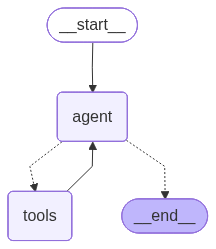

In [ ]:
from langgraph.prebuilt import create_react_agent
from IPython.display import Image, display


answer_reviewer = create_react_agent(
    llm, 
    tools=tools, 
    state_modifier=evaluation_prompt,
    )

display(Image(answer_reviewer.get_graph().draw_mermaid_png()))

In [ ]:
from langchain_core.messages import HumanMessage

messages = [HumanMessage(content=f"""[질문]\n\{value['question']}n\n[답변]\n{value['final_answer']}""")]
messages = answer_reviewer.invoke({"messages": messages})
for m in messages['messages']:
    m.pretty_print()

================================ Human Message =================================

[질문]
\한국은행법에서 규정하는 통화정책 수단과 국채 인수 제한이 소비자물가지수(CPI) 안정과 물가안정 정책에 어떤 영향을 미치는가?n
[답변]
한국은행법에 따라 한국은행은 물가안정목표를 설정하고 이를 달성하기 위해 통화정책 수단을 활용합니다 (한국은행법 제6조). 이러한 통화정책 수단은 금리 조정, 공개시장 조작, 지급준비율 조정 등을 포함하며, 물가를 안정시키는 데 기여합니다 (출처: KDI 연구 분석, https://www.kdi.re.kr/research/analysisView?art_no=3626). 

국채 인수 제한은 정부의 재정정책과 통화정책 간의 조화를 유지하여 물가안정에 긍정적인 영향을 미칩니다 (출처: 일반적인 경제 이론). 이는 정부가 과도한 재정적자를 피하도록 하여 통화정책의 효과성을 높이는 역할을 합니다. 

결과적으로, 한국은행의 통화정책 수단은 소비자물가지수(CPI)의 안정에 긍정적인 영향을 미치며, 물가상승률에 지속적인 영향을 미치는 중요한 요소입니다 (출처: KDI 연구 분석, https://www.kdi.re.kr/research/analysisView?art_no=3626).
================================== Ai Message ==================================
Tool Calls:
  Bank_of_Korea_act_search (call_velmG5q6UHuIIx6NWMrYRhyR)
 Call ID: call_velmG5q6UHuIIx6NWMrYRhyR
  Args:
    query: 통화정책 수단
  Price_Stabilization_act_search (call_pRhBIDt0s46VYwpAHAreRx4Q)
 Call ID: call_pRhBIDt0s46VYwpAHAreRx4Q
  Args:
    query:

In [85]:
json.loads(m.content).keys()

dict_keys(['scores', 'total_score', 'brief_evaluation'])

In [86]:
print(json.loads(m.content)['total_score'])

49


In [ ]:
def evaluate_answer_node(state:ResearchAgentState):
    question = state["question"]
    final_answer = state["final_answer"]

    messages = [HumanMessage(content=f"""[질문]\n\{question}n\n[답변]\n{final_answer}""")]
    response = answer_reviewer.invoke({"messages": messages})
    response_dict = json.loads(response['messages'][-1].content)

    return {"evaluation_report": response_dict, "question": question, "final_answer": final_answer}

def human_review(state: ResearchAgentState):
    print("\n현재 답변:")
    print(state['final_answer'])
    print("\n평가 결과:")
    print(f"총점: {state['evaluation_report']['total_score']}/60")
    print(state['evaluation_report']['brief_evaluation'])
    
    user_input = input("\n이 답변을 승인하시겠습니까? (y/n): ").lower()
    
    if user_input == 'y':
        return "approved"
    else:
        return "rejected"
    

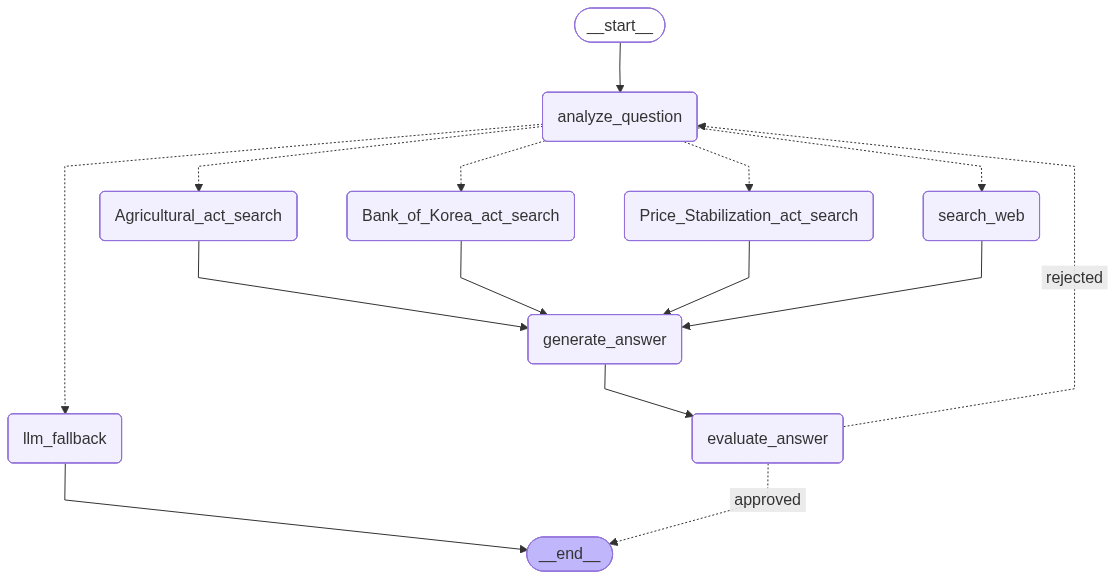

In [ ]:
nodes = {
    "analyze_question": analyze_question_tool_search,
    "Bank_of_Korea_act_search": Bank_of_Korea_rag_node,
    "Agricultural_act_search": Agricultural_rag_node,
    "Price_Stabilization_act_search": Price_Stabilization_rag_node,
    "search_web": web_rag_node,
    "generate_answer": answer_final,
    "llm_fallback": llm_fallback,
    "evaluate_answer": evaluate_answer_node, 
}

search_builder = StateGraph(ResearchAgentState)

for node_name, node_func in nodes.items():
    search_builder.add_node(node_name, node_func)

search_builder.add_edge(START, "analyze_question")
search_builder.add_conditional_edges(
    "analyze_question",
    route_datasources_tool_search,
    ["Bank_of_Korea_act_search", "Agricultural_act_search", "Price_Stabilization_act_search", "search_web", "llm_fallback"]
)

for node in ["Bank_of_Korea_act_search", "Agricultural_act_search", "Price_Stabilization_act_search", "search_web"]:
    search_builder.add_edge(node, "generate_answer")

search_builder.add_edge("generate_answer", "evaluate_answer")

search_builder.add_conditional_edges(
    "evaluate_answer",
    human_review,
    {
        "approved": END,
        "rejected": "analyze_question"  
    }
)

search_builder.add_edge("llm_fallback", END)

legal_rag_agent = search_builder.compile()

display(Image(legal_rag_agent.get_graph().draw_mermaid_png()))

In [89]:
inputs = {"question": "물가안정에 관한 법률에서 규정하는 정부의 가격조정 및 긴급조치 권한이 소비자물가지수(CPI) 안정 정책과 어떻게 연계되는가?"}
for output in legal_rag_agent.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

"Node 'analyze_question':"
"Value: {'datasources': ['Price_Stabilization_act_search', 'search_web']}"

----------------------------------------------------------

--- 물가안정에 관한 법률 전문가 에이전트 시작 ---
---문서 검색---
--- 인터넷 검색 전문가 에이전트 시작 ---
---문서 검색---
---정보 추출 및 평가---
---정보 추출 및 평가---
---답변 생성---
---답변 생성---
"Node 'search_web':"
("Value: {'answers': ['# 물가안정에 관한 법률과 소비자물가지수(CPI) 안정 정책의 연계\\n\\n물가안정에 관한 법률은 "
 '정부에게 가격조정 및 긴급조치 권한을 부여하며, 이는 소비자물가지수(CPI)의 안정성을 유지하기 위한 중요한 정책 수단으로 작용합니다. '
 '정부의 가격조정 및 긴급조치 권한은 CPI의 변동을 관리하고, 이를 통해 물가안정에 기여합니다.\\n\\n## 관련 출처 및 링크\\n- '
 '물가안정에 관한 법률 (출처: 물가안정에 관한 법률)\\n- 소비자물가지수 관련 자료 (출처: 소비자물가지수 관련 자료)\\n- 물가안정 '
 '정책 관련 자료 (출처: 물가안정 정책 관련 자료)\\n\\n## 추가 설명\\n소비자물가지수(CPI)는 전체 소비자물가대상 상품과 '
 '서비스를 포괄하여 물가의 흐름을 보여주는 지표입니다. CPI의 변동은 정부의 가격조정 정책에 의해 영향을 받을 수 있으며, 이는 물가안정 '
 '정책의 일환으로 경제 전반의 안정성을 도모하는 데 기여합니다. 예를 들어, 특정 상품의 가격이 급등할 경우 정부는 가격조정 조치를 통해 '
 'CPI의 급격한 변동을 완화할 수 있습니다.\\n\\n## 결론 및 요약\\n물가안정에 관한 법률은 정부가 가격조정 및 긴급조치를 통해 '
 '소비자물가지수의 안정성을 유지할 수 있도록 하는 법적 근

In [90]:
value

{'question': '물가안정에 관한 법률에서 규정하는 정부의 가격조정 및 긴급조치 권한이 소비자물가지수(CPI) 안정 정책과 어떻게 연계되는가?',
 'final_answer': '물가안정에 관한 법률에 따라 정부는 물가가 급격히 오르고 물품 공급이 부족할 때 긴급수급조정조치를 취할 수 있으며, 이는 소비자물가지수(CPI) 안정 정책과 밀접하게 연관되어 있습니다 (물가안정에 관한 법률 제6조 ①항). 이러한 조치는 국민생활의 안정을 해치고 국민경제의 원활한 운영을 저해할 우려가 있을 때 시행됩니다 (물가안정에 관한 법률 제6조 ①항).\n\n정부의 가격조정 및 긴급조치 권한은 CPI의 변동을 관리하고, 이를 통해 물가안정에 기여합니다 (출처: 물가안정에 관한 법률). 예를 들어, 특정 필수품의 공급이 부족할 경우, 정부는 수출입을 조절하거나 생산계획을 변경하여 공급을 늘리고 가격을 안정시킬 수 있습니다. 이러한 조치는 CPI에 직접적인 영향을 미쳐 물가 상승을 억제하고 소비자에게 안정된 가격을 제공하는 데 기여합니다 (출처: 물가안정에 관한 법률). \n\n결론적으로, 물가안정에 관한 법률은 정부가 가격조정 및 긴급조치를 통해 소비자물가지수의 안정성을 유지할 수 있도록 하는 법적 근거를 제공합니다 (물가안정에 관한 법률 제6조).',
 'evaluation_report': {'scores': {'accuracy': 9,
   'relevance': 10,
   'completeness': 9,
   'citation_accuracy': 8,
   'clarity_conciseness': 9,
   'objectivity': 9},
  'total_score': 54,
  'brief_evaluation': '답변은 물가안정에 관한 법률과 소비자물가지수(CPI) 안정 정책 간의 관계를 잘 설명하고 있으며, 관련 법률 조항을 인용하여 정확성을 높였습니다. 그러나 인용의 구체성이 다소 부족하여 점수를 약간 낮췄습니다.'}}

In [92]:
inputs = {"question": "물가안정물가가 급격히 상승할 경우, 물가안정에 관한 법률에서 규정한 정부의 긴급조치 권한은 무엇인가요?"}
for output in legal_rag_agent.stream(inputs):
    for key, value in output.items():
        # 노드 출력
        pprint(f"Node '{key}':")
        pprint(f"Value: {value}", indent=2, width=80, depth=None)
    print("\n----------------------------------------------------------\n")

"Node 'analyze_question':"
"Value: {'datasources': ['Price_Stabilization_act_search', 'search_web']}"

----------------------------------------------------------

--- 물가안정에 관한 법률 전문가 에이전트 시작 ---
---문서 검색---
--- 인터넷 검색 전문가 에이전트 시작 ---
---문서 검색---
---정보 추출 및 평가---
---정보 추출 및 평가---
---답변 생성---
---답변 생성---
"Node 'search_web':"
("Value: {'answers': ['# 물가안정물가가 급격히 상승할 경우 정부의 긴급조치 권한\\n\\n정부는 물가가 급격히 상승하고 "
 '물품의 공급이 부족하여 국민생활의 안정과 국민경제의 원활한 운영이 현저하게 저해될 우려가 있을 때, **긴급수급조정조치를 취할 수 '
 '있습니다**. 이는 물가안정에 관한 법률 제6조에 명시된 정부의 권한으로, 물가 상승과 공급 부족 상황에서 국민생활을 보호하기 위한 '
 '조치입니다.\\n\\n## 관련 출처 및 링크\\n- 물가안정에 관한 법률 제6조 (출처: 법률 제6조)\\n\\n## 추가 '
 '설명\\n긴급수급조정조치는 물가안정과 국민생활의 안정을 도모하기 위해 정부가 발동할 수 있는 조치로, 물가 상승과 공급 부족이 동시에 '
 '발생할 경우에 적용됩니다. 이러한 조치는 국민경제의 원활한 운영을 저해할 우려가 있을 때에만 시행됩니다.\\n\\n## 결론 및 '
 '요약\\n물가가 급격히 상승하고 공급이 부족할 경우, 정부는 긴급수급조정조치를 통해 국민생활을 보호하고 경제의 안정을 도모할 수 있는 '
 '권한을 가지고 있습니다. 이는 물가안정에 관한 법률에 명시된 중요한 조치로, 경제적 위기 상황에서 국민의 생활을 지키기 위한 필수적인 '
 "권한입니다.']}")

--------------------------------------

In [93]:
value

{'question': '물가안정물가가 급격히 상승할 경우, 물가안정에 관한 법률에서 규정한 정부의 긴급조치 권한은 무엇인가요?',
 'final_answer': '물가가 급격히 상승하고 물품 공급이 부족할 경우, 정부는 물가안정에 관한 법률에 따라 **긴급수급조정조치를 취할 수 있는 권한**을 가지고 있습니다 (물가안정에 관한 법률 제6조 ①항). 이 조치는 생산계획의 수립 및 변경, 공급 및 출고에 관한 지시, 수출입 조절, 운송 및 보관, 유통조직 정비 등을 포함합니다 (물가안정에 관한 법률 제6조 ①항 1~5호). \n\n이러한 조치를 시행하기 위해서는 **국무회의의 심의를 거쳐 대통령의 승인을 받아야** 하며 (물가안정에 관한 법률 제6조 ③항), 조치는 **5개월 이내의 기간**을 정하여 시행될 수 있습니다 (물가안정에 관한 법률 제6조 ①항). 또한, 정부는 긴급수급조정조치를 한 후 그 사유가 없어졌을 때 즉시 해제해야 합니다 (물가안정에 관한 법률 제6조 ②항).',
 'evaluation_report': {'scores': {'accuracy': 10,
   'relevance': 10,
   'completeness': 10,
   'citation_accuracy': 10,
   'clarity_conciseness': 9,
   'objectivity': 10},
  'total_score': 59,
  'brief_evaluation': '답변은 물가안정에 관한 법률의 긴급조치 권한에 대해 정확하고 관련성 있게 설명하였으며, 법률 조항을 인용하여 신뢰성을 높였습니다. 다만, 약간의 문장 구조 개선이 필요할 수 있습니다.'}}

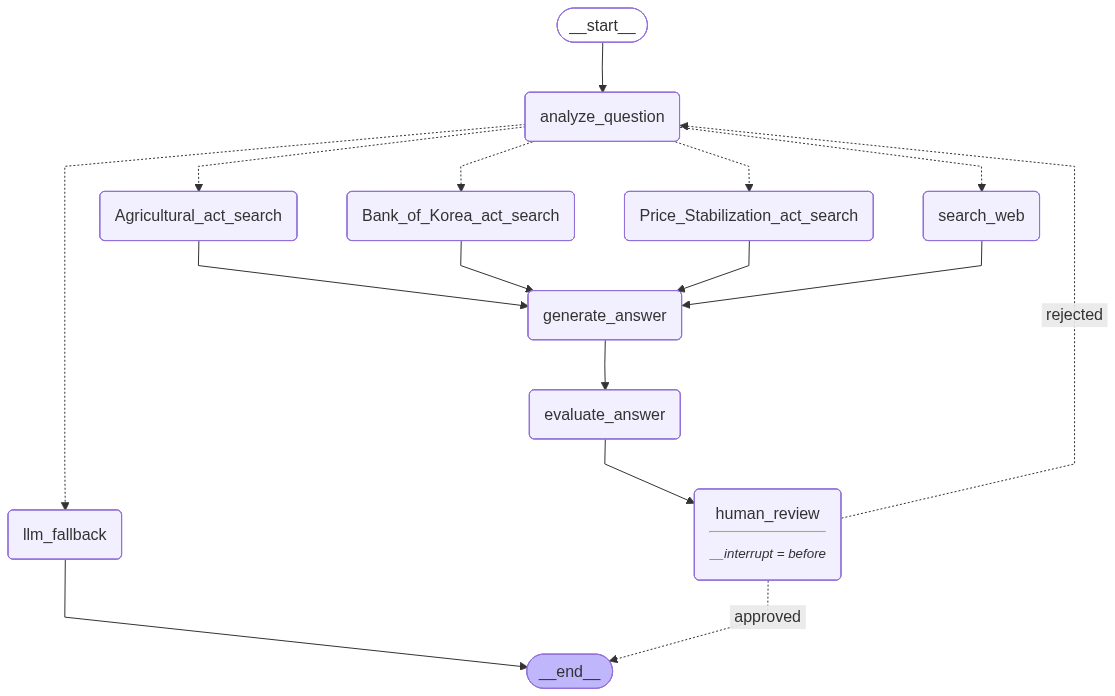

In [ ]:
from langgraph.checkpoint.memory import MemorySaver

def human_review(state: ResearchAgentState):
    pass

search_builder = StateGraph(ResearchAgentState)

nodes = {
    "analyze_question": analyze_question_tool_search,
    "Bank_of_Korea_act_search": Bank_of_Korea_rag_node,
    "Agricultural_act_search": Agricultural_rag_node,
    "Price_Stabilization_act_search": Price_Stabilization_rag_node,
    "search_web": web_rag_node,
    "generate_answer": answer_final,
    "llm_fallback": llm_fallback,
    "evaluate_answer": evaluate_answer_node, 
    "human_review": human_review,
}

for node_name, node_func in nodes.items():
    search_builder.add_node(node_name, node_func)

search_builder.add_edge(START, "analyze_question")
search_builder.add_conditional_edges(
    "analyze_question",
    route_datasources_tool_search,
    ["Bank_of_Korea_act_search", "Agricultural_act_search", "Price_Stabilization_act_search", "search_web", "llm_fallback"]
)

for node in ["Bank_of_Korea_act_search", "Agricultural_act_search", "Price_Stabilization_act_search", "search_web"]:
    search_builder.add_edge(node, "generate_answer")

search_builder.add_edge("generate_answer", "evaluate_answer")
search_builder.add_edge("evaluate_answer", "human_review")

search_builder.add_conditional_edges(
    "human_review",
    lambda x: "approved" if x.get("user_decision") == "approved" else "rejected",
    {
        "approved": END,
        "rejected": "analyze_question"
    }
)

search_builder.add_edge("llm_fallback", END)

memory = MemorySaver()

legal_rag_agent = search_builder.compile(checkpointer=memory, interrupt_before=["human_review"])

display(Image(legal_rag_agent.get_graph().draw_mermaid_png()))

In [ ]:
import gradio as gr
import uuid
from typing import List, Tuple
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
legal_rag_agent = search_builder.compile(checkpointer=memory, interrupt_before=["human_review"])

example_questions = [
    "한국은행법에서 규정하는 통화정책 수단과 국채 인수 제한이 소비자물가지수(CPI)에 어떤 영향을 미치는가요?",
    "농수산물 유통 및 가격안정에 관한 법률의 목적이 무엇인가요?",
    "물가가 급격히 상승할 경우, 물가안정에 관한 법률에서 규정한 정부의 긴급조치 권한은 무엇인가요?",
]

class ChatBot:
    def __init__(self):
        self.thread_id = str(uuid.uuid4())
        self.user_decision = False

    def process_message(self, message: str) -> str:
        try:
            config = {"configurable": {"thread_id": self.thread_id}}
            
            if not self.user_decision:
                inputs = {"question": message}
                legal_rag_agent.invoke(inputs, config=config)

                current_state = legal_rag_agent.get_state(config)
                print("Current state:", current_state)
                
                final_answer = current_state.values.get("final_answer", "No answer available")
                evaluation_report = current_state.values.get('evaluation_report', {'total_score': 0, 'brief_evaluation': 'No evaluation available'})
                
                response = f"""현재 답변:
            {final_answer}

            평가 결과:
            총점: {evaluation_report.get('total_score', 0)}/60
            {evaluation_report.get('brief_evaluation', 'No evaluation available')}

            이 답변을 승인하시겠습니까? (y/n): """
                
                self.user_decision = True
                return response
                
            else:
                user_decision = message.lower()
                if user_decision == 'y':
                    self.user_decision = False 
                    legal_rag_agent.update_state(config, {"user_decision": "approved"})
                    legal_rag_agent.invoke(None, config=config)
                    print("Final state:", current_state)
                    return current_state.values.get("final_answer", "No final answer available")
                else:
                    self.user_decision = False  
                    legal_rag_agent.update_state(config, {"user_decision": "rejected"}) 
                    legal_rag_agent.invoke(None, config=config)
                    current_state = legal_rag_agent.get_state(config)
                    print("Revised state:", current_state)
                    
                    final_answer = current_state.values.get("final_answer", "No answer available")
                    evaluation_report = current_state.values.get('evaluation_report', {'total_score': 0, 'brief_evaluation': 'No evaluation available'})
                    
                    response = f"""다시 생성한 답변:
                {final_answer}

                평가 결과:
                총점: {evaluation_report.get('total_score', 0)}/60
                {evaluation_report.get('brief_evaluation', 'No evaluation available')}

                이 답변을 승인하시겠습니까? (y/n): """
                    
                    self.user_decision = True
                    return response

        except Exception as e:
            print(f"Error occurred: {str(e)}")
            return "죄송합니다. 응답을 생성하는 동안 오류가 발생했습니다. 다시 시도해 주세요."

    def chat(self, message: str, history: List[Tuple[str, str]]) -> str:
        print(f"Thread ID: {self.thread_id}")
        response = self.process_message(message)
        return response

chatbot = ChatBot()

# ChatInterface 생성
demo = gr.ChatInterface(
    fn=chatbot.chat,
    title="BigMac AI 어시스턴트",
    description="한국은행법, 농수산물 유통 및 가격안정에 관한 법률, 물가안정에 관한 법률 관련 질문에 답변해 드립니다.",
    examples=example_questions,
    theme=gr.themes.Soft()
)

demo.launch(share=True)

Running on local URL:  http://127.0.0.1:7861
Running on public URL: https://f441ce1735dc5ae620.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


Thread ID: 4c7bd2ef-f669-4b60-9c92-f1ff650081a7
--- 한국은행법 전문가 에이전트 시작 ---
--- 인터넷 검색 전문가 에이전트 시작 ---
---문서 검색---
---문서 검색---
---정보 추출 및 평가---
---정보 추출 및 평가---
---답변 생성---
---답변 생성---
---최종 답변---
Current state: StateSnapshot(values={'question': '한국은행법에서 규정하는 통화정책 수단과 국채 인수 제한이 소비자물가지수(CPI)에 어떤 영향을 미치는가요?', 'answers': ['# 한국은행법에서 규정하는 통화정책 수단과 국채 인수 제한이 소비자물가지수(CPI)에 미치는 영향\n\n## 1. 직접적인 답변\n한국은행법에 따라 한국은행은 물가안정목표를 설정하고 이를 달성하기 위해 다양한 통화정책 수단을 활용합니다. 이러한 정책은 소비자물가지수(CPI)에 직접적인 영향을 미칠 수 있습니다. 특히, 통화정책 수단의 조정은 금리 변화와 유동성 조절을 통해 물가에 영향을 미치며, 국채 인수 제한은 정부의 재정 정책과 통화 정책 간의 조화를 이루는 데 기여합니다.\n\n## 2. 관련 법률 조항 및 해석\n한국은행법 제6조에 따르면, 한국은행은 정부와 협의하여 물가안정목표를 정하고, 이를 달성하기 위해 최선을 다해야 합니다. 이는 통화정책 수단을 통해 물가를 안정시키려는 한국은행의 의무를 명시하고 있습니다. 이러한 목표는 소비자물가지수(CPI)와 밀접한 관련이 있으며, 통화정책의 변화는 CPI에 직접적인 영향을 미칠 수 있습니다 (출처: 한국은행법 제6조).\n\n## 3. 추가 설명 또는 예시\n예를 들어, 한국은행이 금리를 인상하면 대출 비용이 증가하고 소비자와 기업의 지출이 줄어들 수 있습니다. 이는 수요 감소로 이어져 물가 상승률이 낮아질 수 있습니다. 반대로, 금리를 인하하면 소비와 투자가 촉진되어 물가 상승 압력이 증가할 수 있습니다. 또한, 국채 인수 제한은 정부의 재정적

In [ ]:
demo.close()

Closing server running on port: 7861


: 